<center>МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИЙСКОЙ ФЕДЕРАЦИИ </center>
<center>ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ ОБРАЗОВАТЕЛЬНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ </center>
<center>«НОВОСИБИРСКИЙ ГОСУДАРСТВЕННЫЙ ТЕХНИЧЕСКИЙ УНИВЕРСИТЕТ»</center>
<center>Кафедра Вычислительной техники </center>
<br>
<center> <b> <font size="5">  ОТЧЁТ </font>  </b>  </center>   
<center><font size="3">по лабораторной работе №3</font></center>
<center><font size="3">по дисциплине: «Системы искусственного интеллекта и машинное обучение» </font></center>
<br>

Выполнили:
- Болотенко Н.А.
- Левицкий А.В.

Проверил: Пронюшкина А.Н.

<center>  Новосибирск, 2025  </center>


## Цель работы

Знакомство и работа с моделью машинного обучения типа "многослойный перцептрон" для решения задачи регрессии с использованием библиотеки Tensorflow.

## Основная часть
---

### Подключение пакетов

Перед началом работы нужно убедиться, что необходимые для работы пакеты установлены в системе.

In [1]:
import sys
print(f"Версия Python - {sys.version}")
print(f"Путь к интерпретатору Python - {sys.executable}")

Версия Python - 3.10.11 | packaged by conda-forge | (main, May 10 2023, 18:58:44) [GCC 11.3.0]
Путь к интерпретатору Python - /home/kavalord/miniconda3/envs/ml_labs/bin/python


In [2]:

import pandas as pd
import numpy  as np

import sklearn
from sklearn import linear_model
from sklearn import ensemble
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from matplotlib import pyplot as plt
from matplotlib import cm
import seaborn as sns

import tensorflow as tf
from IPython.display import clear_output
import plotly.graph_objects as go

### Объявление функций 

In [3]:
def plot_difference(y_test, y_pred) -> None:
    '''
    Функция построения графиков
    :param y_test: - проверочные значения целевой переменной
    :param y_pred: - вычисленные значения целевой переменной
    '''
    plt.figure(figsize=(12,6))
    
    plt.subplot(121)
    plt.scatter(y_test, y_pred,  alpha=0.1, color = "#17becf")
    plt.axline((0, 0), slope=1, color='black', linestyle='--', linewidth=3, alpha=0.7,)
    range_test, range_pred = np.max(y_test)- np.min(y_test) , np.max(y_pred)- np.min(y_pred)
    if range_test/range_pred <4 and range_test/range_pred > 0.25:
        plt.gca().set_aspect('equal')
        axmin, axmax = np.min([y_test, y_pred]), np.max([y_test, y_pred])
        plt.xlim([axmin, axmax]); plt.ylim([axmin, axmax]);
    plt.title('Диаграмма рассеяния вычисленных значений');
    plt.xlabel('Проверочное Y')
    plt.ylabel('Вычисленное Y')
    plt.grid(True)

    plt.subplot(122) # 1 row, 2 column, 2 index on grid
    plt.scatter(y_test, (y_test - y_pred)**2,  alpha=0.1, color = "#17becf")
    plt.title('Диаграмма рассеяния квадрата абсолютной ошибки')
    plt.xlabel('Проверочное Y')
    plt.ylabel('Квадрат абсолютной ошибки')
    plt.grid(True)

In [4]:
def stats(y_test, y_pred):
    '''
    Вычисление и вывод метрик: MAE, RMSE, R2. Используются функции из библиотеки sklearn
    На основе сравнения проверочных и вычисленных.
    :param y_test: - проверочные значения целевой переменной
    :param y_pred: - вычисленные значения целевой переменной
    '''
    mae  = metrics.mean_absolute_error(y_test, y_pred)
    mse  = metrics.mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = metrics.r2_score(y_test, y_pred)
    print ("MAE : {:>9,.3f} (средняя абсолютная ошибка)".format(mae))
    print ("MSE : {:>9,.6f} (среднеквадратичная ошибка)".format(mse))
    print ("RMSE: {:>9,.6f} (кв. корень из среднеквадратичной ошибки)".format(rmse))
    print ("R2  : {:>9,.3f} (коэфф. детерминации)".format(r2))
    return {"MAE":mae, "MSE":mse, "RMSE":rmse, "R2":r2}

In [5]:
def my3dplot (  x_train: pd.DataFrame, y_train: pd.DataFrame,  isDrawTrain: bool,
                x_test:  pd.DataFrame, y_test: pd.DataFrame,    isDrawTest: bool,
                y_pred:  pd.DataFrame,            isDrawPred: bool,
                x1Name: str, x2Name: str, y_targetName: str,
                pointSize = 5,
                pointTransparency  = 0.25,
                meshTransparency   = 0.5
                ) -> None:
    """
    Отображает 3D график исходных и вычисленых точек
    x_test, y_test, x_train, y_train - обучающая и проверочная части исходной таблицы  (тип DataFrame)
    y_pred, - вычисленные значения (тип DataFrame)
    x1Name, x2Name - имя столбца для x1 и x2 (тип строковый)
    y_targetName   - имя столбца целевого    (тип строковый)
    """
    trace_ModelPredicted = go.Mesh3d(
                       x= x_test[ x1Name ].values,
                       y= x_test[ x2Name ].values,
                       z= y_pred.reshape(-1), # <-- Вычисленные
                       name="Вычисленный",
                       opacity=meshTransparency,
                       #alphahull=1,
                       color='rgb(244,100,100)',
                      )

    trace_Train = go.Scatter3d (x= x_train[ x1Name ].values,
                                y= x_train[ x2Name ].values,
                                z= y_train.values,
                                name="Обучающие",
                                mode='markers',
                                marker=dict(
                                    size=pointSize,
                                    color='#1f77b4',
                                    opacity=pointTransparency
                                ))

    trace_Test = go.Scatter3d ( x= x_test[ x1Name ].values,
                                y= x_test[ x2Name ].values,
                                z= y_test.values,
                                name="Проверочные",
                                mode='markers',
                                marker=dict(
                                    size=pointSize,
                                    color='#ff7f0e',
                                    opacity=pointTransparency
                               ))

    ListForDraw = []
    if isDrawTrain: ListForDraw.append(trace_Train)
    if isDrawTest:  ListForDraw.append(trace_Test)
    if isDrawPred:  ListForDraw.append(trace_ModelPredicted)

    fig = go.Figure( data=ListForDraw)

    fig.update_layout(
        width=800,
        height=600,
        title='Завиcимость {} от ({}, {})'.format(y_targetName, x1Name, x2Name),
        scene=dict(
            xaxis_title=x1Name,
            yaxis_title=x2Name,
            zaxis_title=y_targetName,
        ),
    )
    fig.show()

In [6]:
def printModelWeights(model):
  for layer in model.layers:
      print(f'{"#"*100}')
      print(f"#### Имя слоя:{layer.name};  Тип слоя: {layer.__class__} ##########", end='')
      print(f"\nВид ф-ии активации слоя: {layer.get_config()['activation']}", end='')
      print(f"\nКол-во ВХодов  слоя: {layer.input.shape[1]}", end='')
      print(f"\nКол-во ВЫХодов слоя: {layer.output.shape[1]}", end='')
      if type(layer) is tf.keras.layers.Dense:
          print(f"\nКол-во нейронов слоя:    {layer.get_config()['units']}", end='')
          print(f"\n\nВесовые коэфф. weight_i_j=\n{layer.weights[0].numpy()}")
          print(f"\nВесовые коэфф. bias_i_j=\n{layer.bias.numpy()}")
      elif type(layer) is tf.keras.layers.Activation:
          pass
      print('\n')

### Tensorflow. Проверка работы нейросети на искусственных данных

Для последующего сравнения получим модель нейронной сети обученной на почти "идеальных" входных данных, т.е. с четко прослеживаемой зависимостью переменных и контролируемым уровнем шумов.

Цель данного шага - продемонстрировать работоспособность применения НС для решения задачи регрессии.

#### Набор данных для демонстрации

Создадим несколько искусственных наборов данных с явной зависимостью ЕДИНСТВЕННОГО y от ЕДИНСТВЕННОГО x.

После создания преобразуем данные к типу pandas.DataFrame, т.к. загруженные данные по варианту будут иметь указанный тип.

Создадим переменную X как набор значений области определения функции в диапазоне [-1.0, 1.0].

In [7]:
N = 1000
X = np.linspace(-1., 1., N).reshape(-1, 1)

Получим набор значения для имитации случайных отклонений для зависимой величины `y`.

In [8]:
noiseLevel= 0.05
Y_noise = np.random.normal(-noiseLevel,noiseLevel,N).reshape(-1, 1)

Используя функции различного вида, получим значения `y` для каждого `x`.

In [9]:
transparencyVal = 0.3  # Прозрачность точек графика
markerSize = 10        # Размер точки графика

Обучим НС для объяснения наложения циклических функций

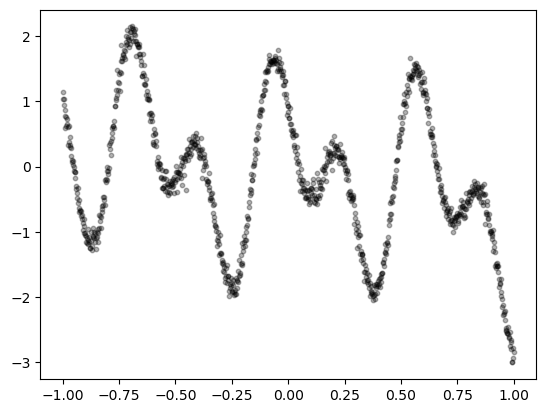

In [10]:
# Наложение циклических функций
Y_hard = np.cos(X*10)  - 1*np.sin(20*X) - 1*X**3
Y_hard = Y_hard+Y_noise*2
plt.scatter(X, Y_hard, s=markerSize, color="black", alpha=transparencyVal)

Но сначала сделаем из данных столбец - будут отдельные записи.

In [11]:
x_train = X.copy().reshape(-1,1)
y_train = Y_hard.copy().reshape(-1,1)

Нормализуем исходные данные для приведения всех значений к единой шкале.

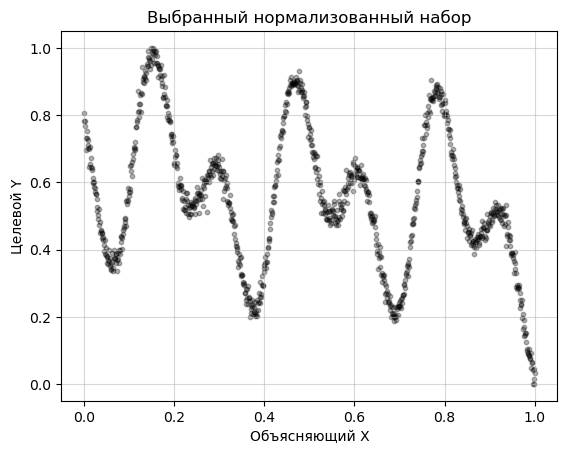

In [12]:
NormalizerX_EXAMPLE = MinMaxScaler().fit(x_train)
NormalizerY_EXAMPLE = MinMaxScaler().fit(y_train)
xNorm_train = NormalizerX_EXAMPLE.transform(x_train)
yNorm_train = NormalizerY_EXAMPLE.transform(y_train)

plt.scatter(xNorm_train, yNorm_train, s=markerSize, color="black", alpha=transparencyVal)
plt.title("Выбранный нормализованный набор")
plt.ylabel("Целевой Y"); plt.xlabel("Объясняющий X");
plt.grid(True, alpha=0.5)  # Сетка.

Структура НС - с использованием [полносвязных слоев](https://adgefficiency.com/guide-deep-learning/#:~:text=The%20fully%20connected%20layer%20is,shape%20of%20the%20output%20layer.), позволяющих объяснять [любую функцию](https://adgefficiency.com/guide-deep-learning/#:~:text=This%20lack%20of%20structure%20is%20what%20gives%20neural%20networks%20of%20fully%20connected%20layers%20(of%20sufficient%20depth%20%26%20width)%20the%20ability%20to%20approximate%20any%20function%20%2D%20known%20as%20the%20Universal%20Approximation%20Theorem.) (см. теорему Цыбенко)

Наша функция сложная - понадобится несколько слоев. Можем использовать следующие [фукнции активации](https://www.tensorflow.org/api_docs/python/tf/keras/activations): *RELU*, зарекомендовавший себя в роли [простого алгоритмически и эффективного](https://towardsdatascience.com/activation-functions-in-neural-networks-how-to-choose-the-right-one-cb20414c04e5/#:~:text=In%20the%20hidden%20layers%2C%20the%20activation%20function%20ReLU%20and%20its%20variants%20have%20established%20themselves%20as%20they%20are%20very%20efficient%20to%20calculate%20and%20at%20the%20same%20time%20avoid%20the%20vanishing%20gradient%20problem%2C%20which%20is%20an%20important%20factor%20in%20this%20area%20of%20architecture.), а также *tanh*, [объясняющего сложные зависимости](https://towardsdatascience.com/activation-functions-in-neural-networks-how-to-choose-the-right-one-cb20414c04e5/#:~:text=It%20is%20also%20a%20non%2Dlinear%20activation%20function%2C%20which%20enables%20the%20model%20to%20learn%20more%20complex%20relationships).

Зададим 3(4) промежуточных слоя, последний будет с гиперболической функцией активации. [Типов слоев](https://www.tensorflow.org/api_docs/python/tf/keras/layers) много, мы же будем использовать обычные плотные слои и отдельную функцию активации.

In [13]:
totalHistoryLossTrain=[] # Вспомогательный список для хранения полной истории обучения
totalHistoryLossTest=[]  # Вспомогательный список для хранения полной истории обучения
globalEpochCounter = 1   # Счётчик выполненных эпох обучения НС

model = tf.keras.models.Sequential()
model.add( tf.keras.layers.Input(shape=(  1 ,))) # Входной слой
# Скрытые слои
# "units" - кол-во узлов у слоя
# "activation" - функция активации
model.add(tf.keras.layers.Dense(units= 500 ,  activation=None))
model.add(tf.keras.layers.Activation( activation=tf.keras.activations.relu))
model.add(tf.keras.layers.Dense(units= 250 ,  activation=tf.keras.activations.relu))
model.add(tf.keras.layers.Dense(units= 50 ,  activation=tf.keras.activations.tanh))
model.add(tf.keras.layers.Dense(units=1,  activation=None)) # Выходной полносвязный слой, Без нелинейной функции активации

fLoss=tf.keras.losses.MeanSquaredError()
fOptimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
fMetricList  = [tf.keras.losses.MeanSquaredError(), tf.keras.losses.MeanAbsoluteError()]

model.compile(
    loss      =fLoss, # Выбор функции оценки ошибок/потерь
    optimizer =fOptimizer, # Выбор функции для минимзации значения выбранной оценки ошибок/потерь
    metrics   = fMetricList # Дополнительные метрики для оценки ошибок/потерь
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        12,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,851 (542.39 KB)

 Trainable params: 138,851 (542.39 KB)

 Non-trainable params: 0 (0.00 B)

None


[Функция ошибок](https://www.tensorflow.org/api_docs/python/tf/keras/losses) позволяет оценивать то, насколько хорошо(или плохо) модель объясняет **тестовые** данные в *процессе обучения*.

currEpochNum: 500/500


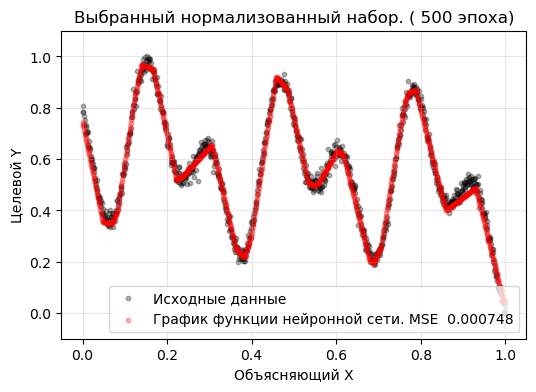

In [14]:
# Выполнить заданное кол-во эпох обучения
epochForTrain = 500 # Кол-во эпох обучения
for currEpochNum in range(1, epochForTrain+1):
    # 3) Цикл обучения/продолжения обучения сети

    # Вызов метода для выполнения обучения (настройки коэфф. нейросети)
    history = model.fit(
        xNorm_train,  # Обучающие X
        yNorm_train,  # Обучающие Y
        #validation_data=(xNorm_test, yNorm_test), # Опционально проверочные X и Y, для вычисления оценок потерь (loss)
        epochs=1,       # Кол-во эпох обучения
        batch_size=100, # Внутри каждой эпохи, проводить обучение пакетами/порциями по batch_size строк
        verbose=1,
    )

    #  Каждые N эпох выводить график текущей функции НС. Только в условиях ЕДИНСТВЕННОГО x.
    if xNorm_train.shape[1] == 1:
        if (currEpochNum) % 10 == 0:
            yNorm_pred = model.predict(xNorm_train, verbose=0) # Вычислить ответы НС
            clear_output(wait=True) # Очистить окно вывода
            print(f'currEpochNum: {currEpochNum}/{epochForTrain}')
            plt.figure(figsize=(6, 4))
            plt.scatter(xNorm_train, yNorm_train,  s=markerSize, color='black', alpha=transparencyVal, label =  'Исходные данные')
            plt.scatter(xNorm_train, yNorm_pred,   s=markerSize, color='red',   alpha=transparencyVal, label = f'График функции нейронной сети. MSE {history.history["loss"][-1]:>9.6f}')
            plt.title(f'Выбранный нормализованный набор. ({globalEpochCounter:>4} эпоха)')
            plt.ylabel('Целевой Y'); plt.xlabel('Объясняющий X');
            plt.ylim( (-0.1, 1.1))
            plt.legend(loc='lower right')
            plt.grid(True, alpha=0.3)
            plt.show()
            plt.pause(0.005) # Временная пауза для отображения графика
    globalEpochCounter+=1

    # Дополнение полной истории обучения
    totalHistoryLossTrain.extend(history.history['loss'])
    if 'val_loss' in history.history.keys():
        totalHistoryLossTest.extend(history.history['val_loss'])

Отобразим изменения значений потерь/ошибок по эпохам в виде графика. По виду этого графика вы можете оценить степень обученности НС

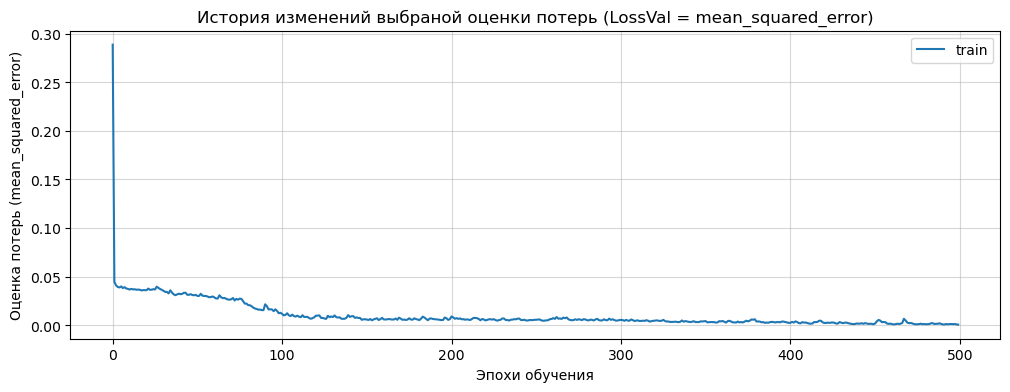

In [15]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения");
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка. Доп параметры color='black', linewidth=0.7
###plt.ylim ( (0, 0.03) ) # Область видимости для оси "Оценки потерь"

Вычислим ответы НС для тренировочных же данных (потому что мы ленивые)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
MAE :     0.020 (средняя абсолютная ошибка)
MSE :  0.000641 (среднеквадратичная ошибка)
RMSE:  0.025323 (кв. корень из среднеквадратичной ошибки)
R2  :     0.985 (коэфф. детерминации)


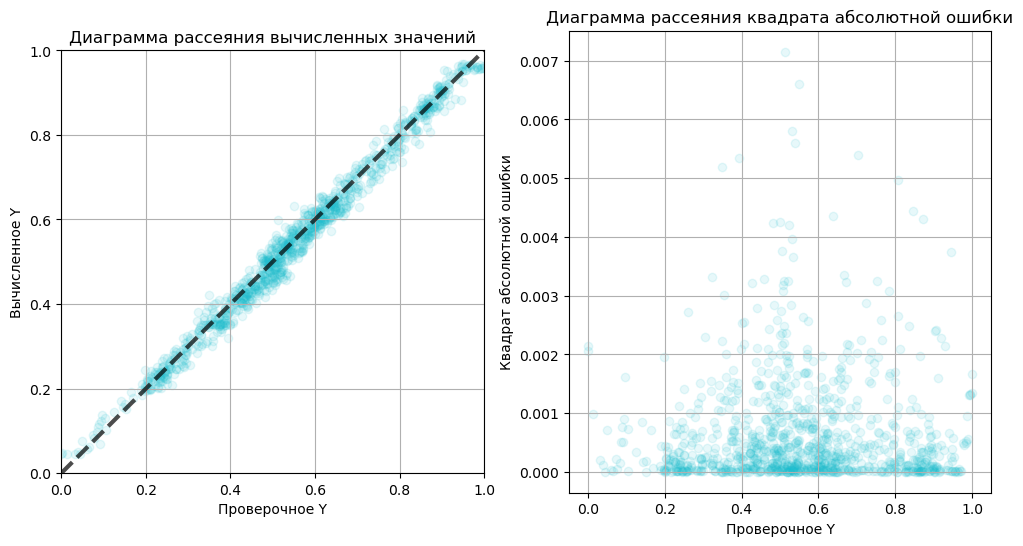

In [16]:
yNorm_pred = model.predict(xNorm_train)
stats(yNorm_train, yNorm_pred)
plot_difference(yNorm_train, yNorm_pred)

### Загрузка подготовленных данных

Структура csv-файла:
- Ячейки разделены ";"
- Дробная часть помечена "."

In [17]:
dataset_file = "datasets/dataset_prepared.csv"
df = pd.read_csv(
    dataset_file,
    sep=';',
    decimal='.',
    header=0
)

df.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco,OcPrx_<1H OCEAN,OcPrx_INLAND,OcPrx_ISLAND,OcPrx_NEAR BAY,OcPrx_NEAR OCEAN
0,352100,7.2574,52,1467.0,190,496,177,37.85,-122.24,8259.085109,554610.7171,733525.6829,64867.28983,18811.48745,0,0,0,1,0
1,342200,3.8462,52,1627.0,280,565,259,37.85,-122.25,7768.086571,555194.2661,734095.2907,65287.13841,18031.04757,0,0,0,1,0
2,269700,4.0368,52,919.0,213,413,193,37.85,-122.25,7768.086571,555194.2661,734095.2907,65287.13841,18031.04757,0,0,0,1,0
3,299200,3.6591,52,2535.0,489,1094,514,37.84,-122.25,6843.020847,554364.4069,733249.8086,64315.99174,17538.20997,0,0,0,1,0
4,241400,3.1200,52,3104.0,687,1157,647,37.84,-122.25,6843.020847,554364.4069,733249.8086,64315.99174,17538.20997,0,0,0,1,0


Выясним размеры датасета

In [18]:
num_rows, num_cols = df.shape
print(f"Размеры набора данных: {num_rows} строк и {num_cols} столбцов\n")
df.info()

Размеры набора данных: 16361 строк и 19 столбцов

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16361 entries, 0 to 16360
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Median_House_Value        16361 non-null  int64  
 1   Median_Income             16361 non-null  float64
 2   Median_Age                16361 non-null  int64  
 3   Tot_Rooms                 16361 non-null  float64
 4   Tot_Bedrooms              16361 non-null  int64  
 5   Population                16361 non-null  int64  
 6   Households                16361 non-null  int64  
 7   Latitude                  16361 non-null  float64
 8   Longitude                 16361 non-null  float64
 9   Distance_to_coast         16361 non-null  float64
 10  Distance_to_LA            16361 non-null  float64
 11  Distance_to_SanDiego      16361 non-null  float64
 12  Distance_to_SanJose       16361 non-null  float64
 13  Distance_to

Целевой признак - Median Income: Медианный доход на семью в квартале[10тыс.$].

Коэфф. корреляции Пирсона позволит выбрать независимые переменные.

In [19]:
target=['Median_Income']
corr_coeffs = df.corr(method='pearson')
corr_coeffs[target[0]].abs().sort_values(ascending=False)

Median_Income               1.000000
Median_House_Value          0.603495
Tot_Rooms                   0.237004
Median_Age                  0.184637
OcPrx_INLAND                0.156272
Distance_to_coast           0.155083
OcPrx_<1H OCEAN             0.136902
Tot_Bedrooms                0.079887
Distance_to_SanJose         0.066688
Population                  0.060554
Distance_to_SanFrancisco    0.050521
Households                  0.046777
Longitude                   0.033349
OcPrx_NEAR BAY              0.026521
OcPrx_NEAR OCEAN            0.026242
Latitude                    0.019742
Distance_to_LA              0.011811
OcPrx_ISLAND                0.011041
Distance_to_SanDiego        0.006869
Name: Median_Income, dtype: float64

В качестве независимых переменных выберем признаки с высоким абс. значением коэфф. корреляции, но при этом как можно более не связанные между собой. Кандидаты:
- *Median_House_Value* - Медианная цена дома в квартале [$]
- *Distance_to_coast*- расстояние до ближайшей точки побережья [м] (или *OcPrx_INLAND*)
- *Tot_Rooms* - Общее количество комнат в квартале
- *Median_Age* - Медианный возраст дома в квартале; меньше = новее [лет]

Дополнительно к ним добавим признак *Population*, в связке с которым при построении линейной модели проявилось свойство синергии - оценка R^2 была самой большой `R^2 = 0.465`

In [20]:
features = ['Median_House_Value', 'Distance_to_coast', 'Tot_Rooms',  'Median_Age', 'Population']

Уберем все прочие признаки

In [21]:
df = df[target +features]
df.head()

,Median_Income,Median_House_Value,Distance_to_coast,Tot_Rooms,Median_Age,Population
0,7.2574,352100,8259.085109,1467.0,52,496
1,3.8462,342200,7768.086571,1627.0,52,565
2,4.0368,269700,7768.086571,919.0,52,413
3,3.6591,299200,6843.020847,2535.0,52,1094
4,3.1200,241400,6843.020847,3104.0,52,1157


### Нормализация данных

Воспользуемся маштабированием через скейлер min-max. По [умолчанию](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#:~:text=feature_rangetuple%20(min%2C%20max)%2C%20default%3D(0%2C%201)) скейлер выдает нормированный диапазон.

In [22]:
minMaxScaler = MinMaxScaler()
df_scaled = pd.DataFrame (
  data    = minMaxScaler.fit_transform(df),
  columns = df.columns,
  index   = df.index
)
df_scaled.head()

,Median_Income,Median_House_Value,Distance_to_coast,Tot_Rooms,Median_Age,Population
0,0.900988,0.725415,0.067896,0.243825,1.0,0.056472
1,0.446167,0.704111,0.063800,0.270527,1.0,0.064376
2,0.471580,0.548097,0.063800,0.152370,1.0,0.046964
3,0.421221,0.611578,0.056082,0.422063,1.0,0.124971
4,0.349342,0.487197,0.056082,0.517023,1.0,0.132188


Построим гистограммы распределения целевого признака

In [23]:
def histograms(df, dfStd, feature_name):
    '''
    Построение гистограмм распределения признака до и после стандартизации
    '''
    plt.figure(figsize=(10,5))

    plt.subplot(121)
    plt.title('Распределение исходных значений')
    plt.xlabel(feature_name)
    plt.ylabel('Количество записей')
    plt.hist(df[feature_name])

    plt.subplot(122)
    plt.title('Распределение нормализованных значений')
    plt.xlabel(feature_name)
    plt.ylabel('Количество записей')
    plt.hist(dfStd[feature_name])

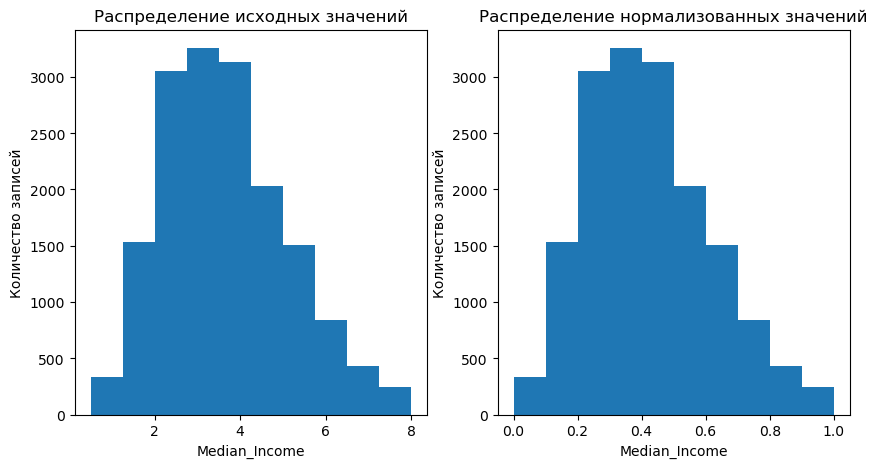

In [24]:
histograms(df, df_scaled, 'Median_Income')

То же сделаем для независимых признаков

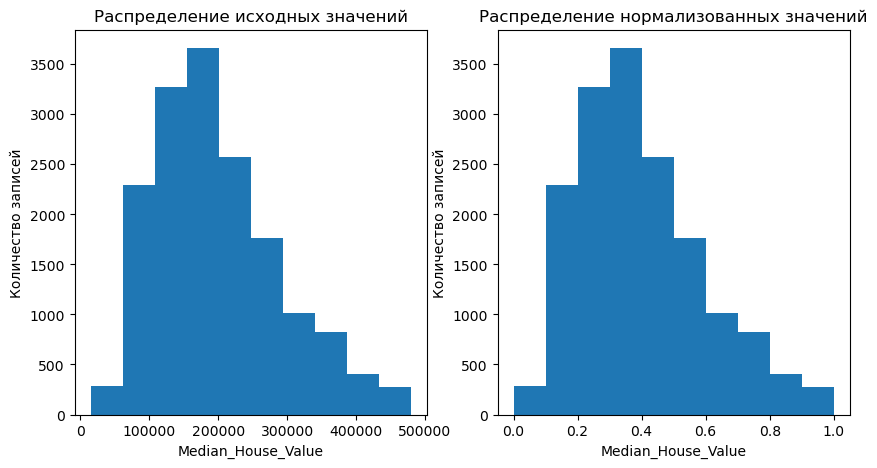

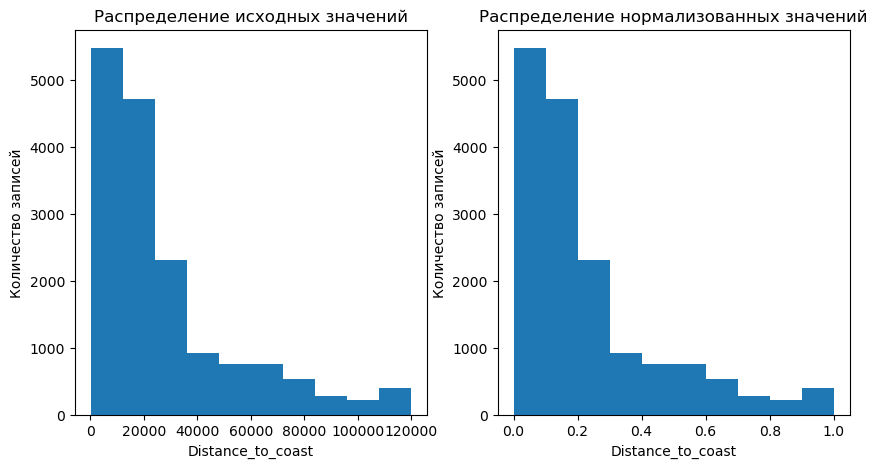

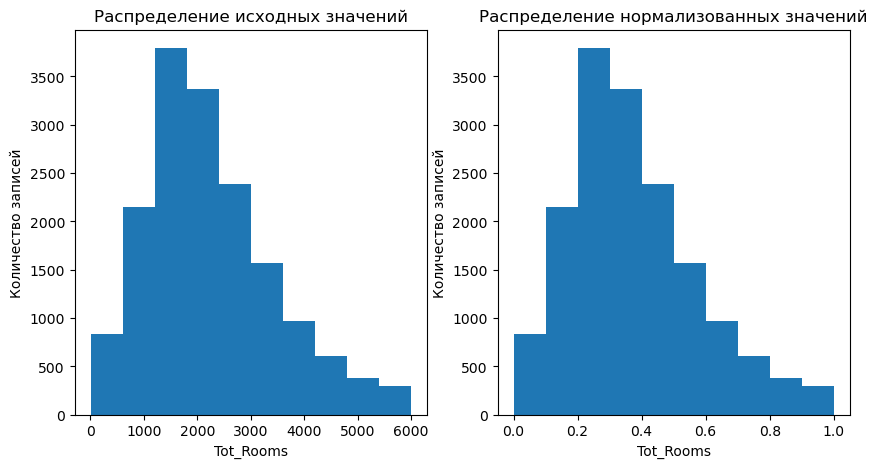

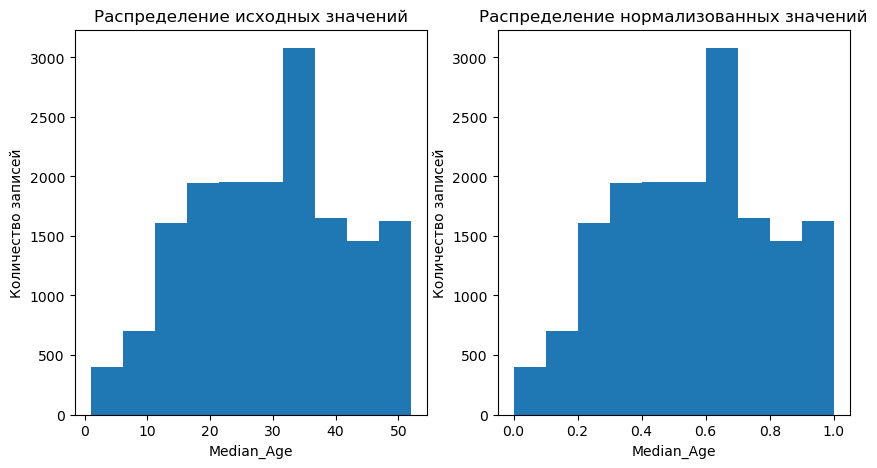

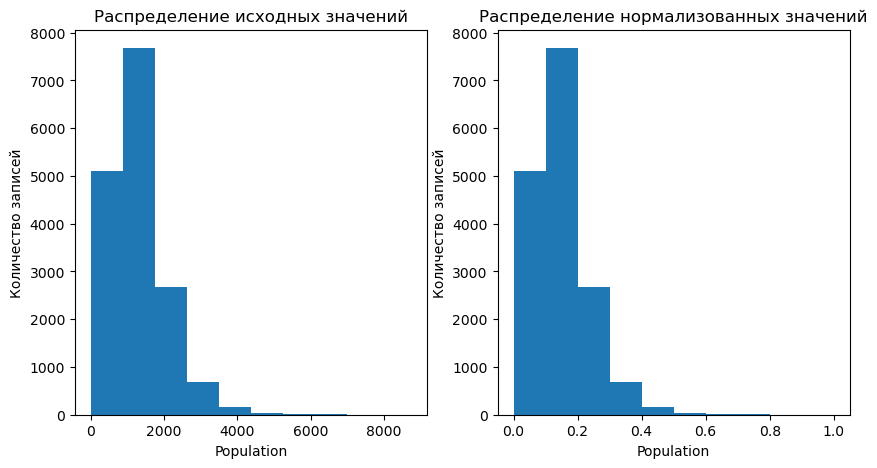

In [25]:
for feat in features:
    histograms(df, df_scaled, feat)

### Формирование тренировочной и проверочной выборок

Зададим сид генератора случайных чисел. А также долю тестовой выборки.

In [26]:
random_state = 42
test_size = 0.3

Разделим выборку на текстовую и тренировочную части.

In [27]:
xNorm_train, xNorm_test, yNorm_train, yNorm_test = train_test_split(
    df_scaled[features],
    df_scaled[target],
    test_size=test_size,
    random_state=random_state,
    shuffle=True
)

yNorm_train = yNorm_train[target[0]]
yNorm_test  = yNorm_test[target[0]]

In [28]:
print ("Кол-во элементов: \n  x_train: {}, y_train {} \n  x_test:  {}, y_test  {} \n  total x: {}, total y {} ".format  (
    len(xNorm_train), len(yNorm_train),
    len(xNorm_test),  len(yNorm_test),
    len(xNorm_train)+len(xNorm_test), len(yNorm_train)+len(xNorm_test),
))

Кол-во элементов: 
  x_train: 11452, y_train 11452 
  x_test:  4909, y_test  4909 
  total x: 16361, total y 16361 


### План работы

Построим модели НС, сосредотачиваясь на нескольких аспектах при постановке экспериментов:

- структуре сети: вход-выход, вход-слои-выход и множество слоев
- количество признаков
- количеству эпох тренировки
- величине групп, которыми обучается модель, *batch size*

### Нейронная сеть m1. Построение модели без скрытых слоев от ДВУХ "x" (2_вх->1_вых)

#### Структура

На НС со структурой 2вх->1вых накладываются требования:

- входной слой должен принимать 2 значения
- скрытые слои отсутствуют
- выходной слой вычисляет единственное значение и не имеет функцию активации

In [ ]:
totalHistoryLossTrain=[]
totalHistoryLossTest=[]

del model

model1 = tf.keras.models.Sequential()
model1.add(tf.keras.layers.Input(shape=(2,)))
model1.add(tf.keras.layers.Dense(units=1,  activation=None))

fLoss=tf.keras.losses.MeanSquaredError()
fOptimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
fMetricList  = [tf.keras.losses.MeanSquaredError(), tf.keras.losses.MeanAbsoluteError()]
model1.compile(
    loss      =fLoss,
    optimizer =fOptimizer,
    # metrics   = fMetricList
)

print(model1.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

None


#### Первичное и дополнительное обучение

Модель от 2х признаков обучим на *Median_House_Value* и *Tot_Rooms*

In [30]:
features21=["Median_House_Value", "Tot_Rooms"]
xNorm_train_21=xNorm_train[features21]
xNorm_test_21=xNorm_test[features21]

Будем тренировать по 100 эпох.

In [31]:
epochForTrain = 100

history = model1.fit(
    xNorm_train_21,
    yNorm_train,
    validation_data=(xNorm_test_21,yNorm_test),
    epochs=epochForTrain,
    #batch_size=100, # внутри каждой эпохи, проводить обучение пакетами/порциями по batch_size строк
    verbose=1,
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0374 - val_loss: 0.0232
Epoch 2/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0229 - val_loss: 0.0229
Epoch 3/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0229 - val_loss: 0.0228
Epoch 4/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0230 - val_loss: 0.0229
Epoch 5/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0229 - val_loss: 0.0229
Epoch 6/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0229 - val_loss: 0.0229
Epoch 7/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0229 - val_loss: 0.0228
Epoch 8/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0229 - val_loss: 0.0229
Epoch 9/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0229 - val_loss: 0.0228
Epoch 10/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0231 - val_loss: 0.0229
Epoch 11/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0230 - val_loss: 0.0230
Epoch 12/100
358/358 ━━━━━━━━━━━━━━━━━━━━

Посмотрим, как изменялась ошибка во времени.

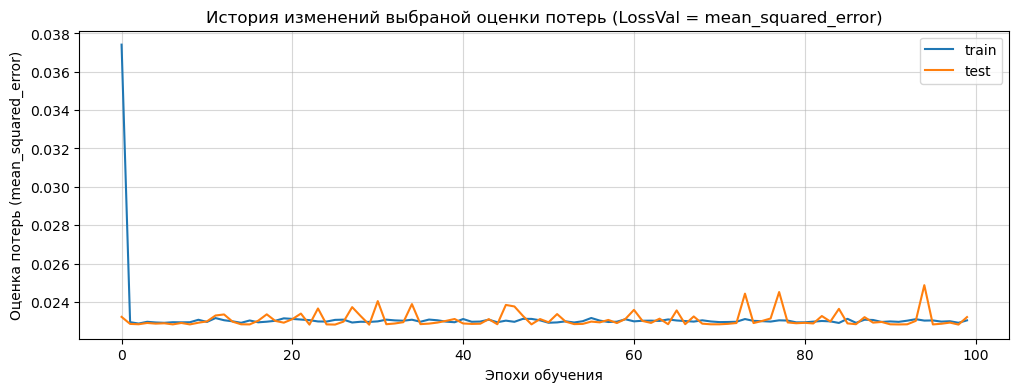

In [32]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
###plt.ylim ( (0, 0.03) ) # Область видимости для оси "Оценки потерь"

И оценим объяснение тестовой выборки. 

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step
MAE :     0.122 (средняя абсолютная ошибка)
MSE :  0.023209 (среднеквадратичная ошибка)
RMSE:  0.152346 (кв. корень из среднеквадратичной ошибки)
R2  :     0.368 (коэфф. детерминации)


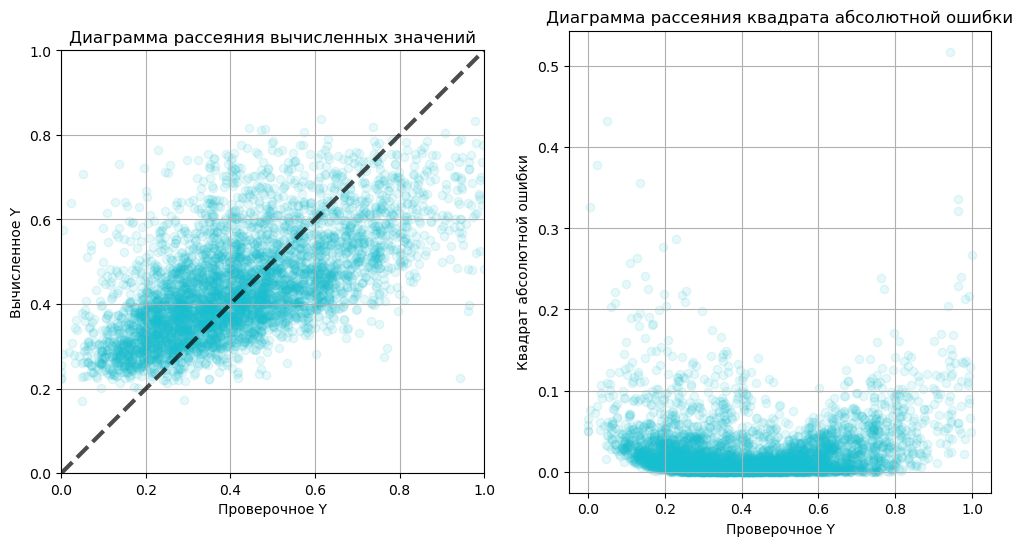

In [33]:
yNorm_pred = model1.predict(xNorm_test_21).reshape(1, -1)[0] # потому что столбец
m1_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

Построим получаемую поверхность

In [34]:
my3dplot(
    xNorm_train_21, yNorm_train,  True, # Обучающие x и y, Флаг отображения обучающих точек  (синие)
    xNorm_test_21,  yNorm_test,   True, # Проверочные x и y, Флаг отображения проверочных точек   (оранжевые)
    yNorm_pred,                True, # Вычисленные y, Флаг отображения вычисленной функции  (зелёные)
    x1Name= features21[0],  x2Name=features21[1], y_targetName=target[0],
    pointSize = 5,
    pointTransparency  = 0.2,
    meshTransparency   = 0.8
)

#### Получение весовых коэфф. w_i и bias для модели m1 (2_вх->1_вых)

Осмотрим параметры и значения весовых коэффициентов каждого отдельного слоя.

Обратим внимание на следующее:
- входной слой Input явно не выделен, но определяет входные параметры следующего за ним слоя;
- весовые коэффициенты при создании уже забиты случайными числами;
- слой с нелинейной функцией активации не имеет коэффициентов

In [35]:
printModelWeights(model1)

####################################################################################################
#### Имя слоя:dense_4;  Тип слоя: <class 'keras.src.layers.core.dense.Dense'> ##########
Вид ф-ии активации слоя: linear
Кол-во ВХодов  слоя: 2
Кол-во ВЫХодов слоя: 1
Кол-во нейронов слоя:    1

Весовые коэфф. weight_i_j=
[[0.5795034 ]
 [0.13434303]]

Весовые коэфф. bias_i_j=
[0.15800412]




### Нейронная сеть m2. Построение модели со скрытыми слоями от ДВУХ "x" (2_вх-> ??? -> ??? ->1_вых)

Теперь построим модель с неколькими скрытыми слоями. Опять же, выбор количества слоев и фунцкий активации зависит от [приложения модели и ее архитектуры](https://towardsdatascience.com/activation-functions-in-neural-networks-how-to-choose-the-right-one-cb20414c04e5/#:~:text=The%20choice%20of%20the%20right,which%20function%20is%20most%20suitable.).

#### Модель с одним промежуточным слоем

Первую модель в эксперименте построим с единственным промежуточным слоем.

##### Структура

In [ ]:
totalHistoryLossTrain=[]
totalHistoryLossTest=[]

del model1

model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Input(shape=(2,)))
model2.add(tf.keras.layers.Dense(units=50,  activation=tf.keras.activations.relu))
model2.add(tf.keras.layers.Dense(units=1,  activation=None))

fLoss=tf.keras.losses.MeanSquaredError()
fOptimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
fMetricList  = [tf.keras.losses.MeanSquaredError(), tf.keras.losses.MeanAbsoluteError()]
model2.compile(
    loss      =fLoss,
    optimizer =fOptimizer,
    metrics   = fMetricList
)

print(model2.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201 (804.00 B)

 Trainable params: 201 (804.00 B)

 Non-trainable params: 0 (0.00 B)

None


##### Первичное и дополнительное обучение

In [37]:
history = model2.fit(
    xNorm_train_21,
    yNorm_train,
    validation_data=(xNorm_test_21,yNorm_test),
    epochs=epochForTrain
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0258 - mean_absolute_error: 0.1261 - mean_squared_error: 0.0258 - val_loss: 0.0248 - val_mean_absolute_error: 0.1263 - val_mean_squared_error: 0.0248
Epoch 2/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0227 - mean_absolute_error: 0.1200 - mean_squared_error: 0.0227 - val_loss: 0.0223 - val_mean_absolute_error: 0.1193 - val_mean_squared_error: 0.0223
Epoch 3/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0227 - mean_absolute_error: 0.1200 - mean_squared_error: 0.0227 - val_loss: 0.0228 - val_mean_absolute_error: 0.1200 - val_mean_squared_error: 0.0227
Epoch 4/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0227 - mean_absolute_error: 0.1197 - mean_squared_error: 0.0227 - val_loss: 0.0223 - val_mean_absolute_error: 0.1185 - val_mean_squared_error: 0.0223
Epoch 5/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0227 - mean_absolute_error: 0.1196 - mean_squared_error: 0.0227 - val_loss: 0.0241 - 

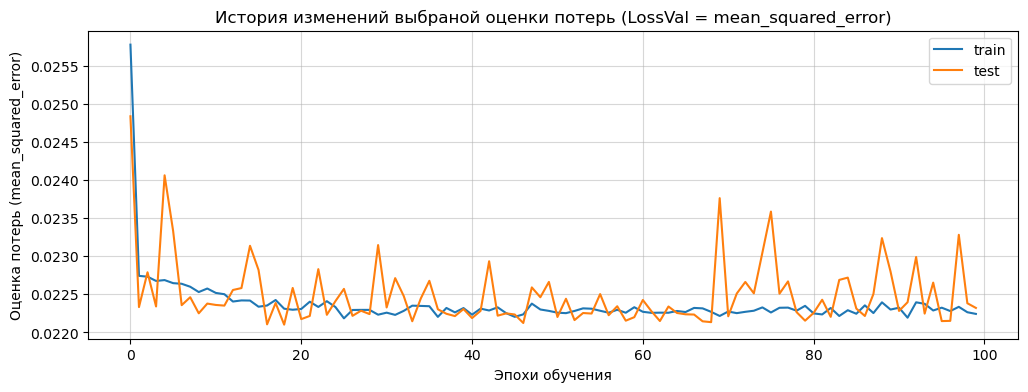

In [38]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
###plt.ylim ( (0, 0.03) ) # Область видимости для оси "Оценки потерь"

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step
MAE :     0.119 (средняя абсолютная ошибка)
MSE :  0.022319 (среднеквадратичная ошибка)
RMSE:  0.149394 (кв. корень из среднеквадратичной ошибки)
R2  :     0.392 (коэфф. детерминации)


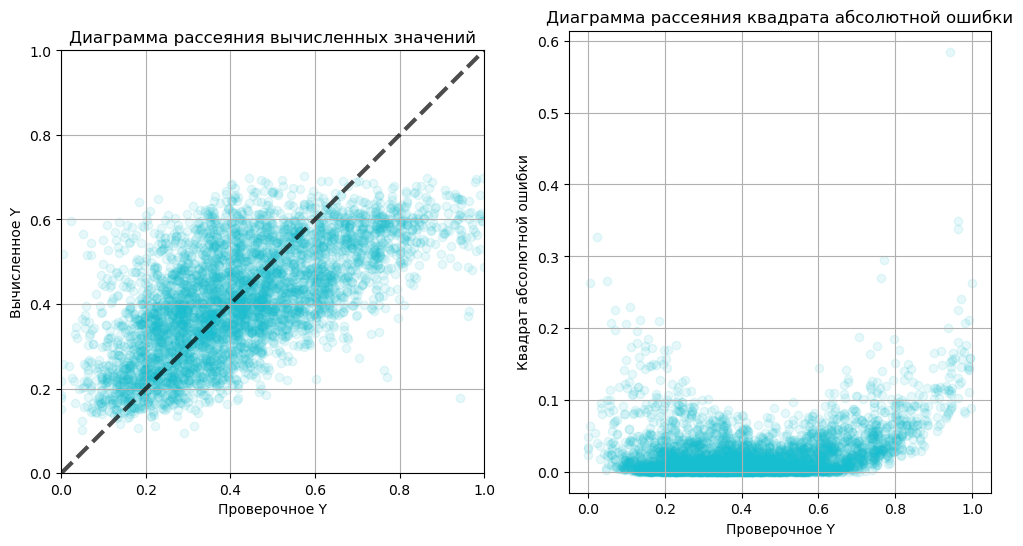

In [39]:
yNorm_pred = model2.predict(xNorm_test_21).reshape(1, -1)[0] # потому что столбец
m_1layer_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

##### Получение весовых коэфф. w_i и bias

Весовых коэффициентов стало много.

In [40]:
printModelWeights(model2)

####################################################################################################
#### Имя слоя:dense_5;  Тип слоя: <class 'keras.src.layers.core.dense.Dense'> ##########
Вид ф-ии активации слоя: relu
Кол-во ВХодов  слоя: 2
Кол-во ВЫХодов слоя: 50
Кол-во нейронов слоя:    50

Весовые коэфф. weight_i_j=
[[ 0.14969935 -0.04102203 -0.27099437 -0.10055292 -0.7291918  -0.15309528
  -0.18503103  0.20342657 -1.6345752   0.07587612  0.2172824  -0.0252426
   0.7631455   0.23721902 -0.18001528  0.20043302 -0.21697669 -0.3263231
   0.08924615 -0.02965087 -0.06217515 -0.3311605  -0.22607237 -0.21193361
  -0.05617574 -0.05222091 -0.01335359 -0.11672998 -0.04045781  0.24779399
  -0.09071627 -0.27860904 -0.06797919  0.01368255 -2.1508105   0.08119997
  -0.21901768 -0.18934177  0.19827919  0.18477623 -0.23588562  0.25635457
   0.09819634 -0.06968734  0.0593299  -0.08994707  0.5157354  -0.30266964
  -0.43138283 -0.13045971]
 [-0.7355769  -0.02115392  0.02099465  0.07718419  0.2211669

Все также построим поверхность

In [41]:
my3dplot(
    xNorm_train_21, yNorm_train,  True, # Обучающие x и y, Флаг отображения обучающих точек  (синие)
    xNorm_test_21,  yNorm_test,   True, # Проверочные x и y, Флаг отображения проверочных точек   (оранжевые)
    yNorm_pred,                True, # Вычисленные y, Флаг отображения вычисленной функции  (зелёные)
    x1Name= features21[0],  x2Name=features21[1], y_targetName=target[0],
    pointSize = 5,
    pointTransparency  = 0.2,
    meshTransparency   = 0.8
)

#### Модель с двумя промежуточными слоями

##### Структура

Введем еще один слой на больее число узлов

In [ ]:
totalHistoryLossTrain=[]
totalHistoryLossTest=[]

del model2

model3 = tf.keras.models.Sequential()
model3.add(tf.keras.layers.Input(shape=(2,)))
model3.add(tf.keras.layers.Dense(units=200,  activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.Dense(units=50,  activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.Dense(units=1,  activation=None))

fLoss=tf.keras.losses.MeanSquaredError()
fOptimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
fMetricList  = [tf.keras.losses.MeanSquaredError(), tf.keras.losses.MeanAbsoluteError()]
model3.compile(
    loss      =fLoss,
    optimizer =fOptimizer,
    metrics   = fMetricList
)

print(model3.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 200)            │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,701 (41.80 KB)

 Trainable params: 10,701 (41.80 KB)

 Non-trainable params: 0 (0.00 B)

None


##### Первичное и дополнительное обучение

In [43]:
# epochForTrain = 40

history = model3.fit(
    xNorm_train_21,
    yNorm_train,
    validation_data=(xNorm_test_21,yNorm_test),
    epochs=epochForTrain,
    #batch_size=100, # внутри каждой эпохи, проводить обучение пакетами/порциями по batch_size строк
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0251 - mean_absolute_error: 0.1244 - mean_squared_error: 0.0251 - val_loss: 0.0228 - val_mean_absolute_error: 0.1197 - val_mean_squared_error: 0.0227
Epoch 2/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0233 - mean_absolute_error: 0.1215 - mean_squared_error: 0.0233 - val_loss: 0.0225 - val_mean_absolute_error: 0.1198 - val_mean_squared_error: 0.0225
Epoch 3/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0228 - mean_absolute_error: 0.1200 - mean_squared_error: 0.0228 - val_loss: 0.0236 - val_mean_absolute_error: 0.1215 - val_mean_squared_error: 0.0235
Epoch 4/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0227 - mean_absolute_error: 0.1199 - mean_squared_error: 0.0227 - val_loss: 0.0225 - val_mean_absolute_error: 0.1200 - val_mean_squared_error: 0.0224
Epoch 5/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0226 - mean_absolute_error: 0.1198 - mean_squared_error: 0.0226 - val_loss: 0.0245 - 

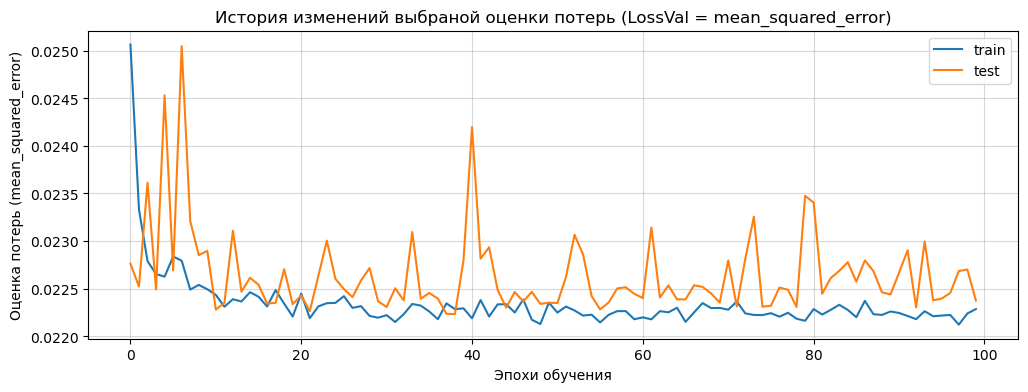

In [44]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
###plt.ylim ( (0, 0.03) ) # Область видимости для оси "Оценки потерь"

Предскажем значения теста

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MAE :     0.119 (средняя абсолютная ошибка)
MSE :  0.022375 (среднеквадратичная ошибка)
RMSE:  0.149582 (кв. корень из среднеквадратичной ошибки)
R2  :     0.390 (коэфф. детерминации)


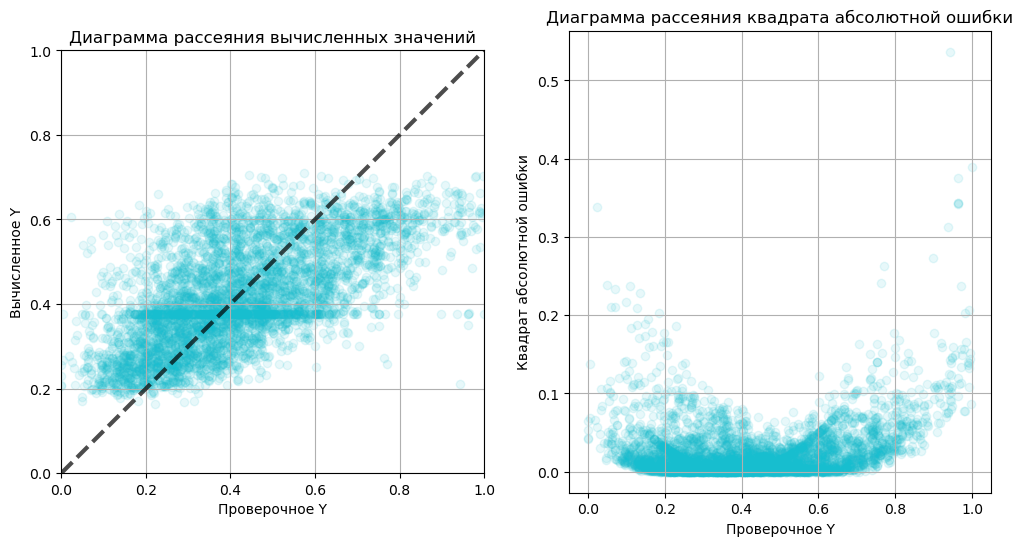

In [45]:
yNorm_pred = model3.predict(xNorm_test_21).reshape(1, -1)[0] # потому что столбец
m_2layers_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

##### Получение весовых коэфф. w_i и bias для модели

In [46]:
printModelWeights(model3)

####################################################################################################
#### Имя слоя:dense_7;  Тип слоя: <class 'keras.src.layers.core.dense.Dense'> ##########
Вид ф-ии активации слоя: relu
Кол-во ВХодов  слоя: 2
Кол-во ВЫХодов слоя: 200
Кол-во нейронов слоя:    200

Весовые коэфф. weight_i_j=
[[ 1.28928572e-01  7.24061206e-02  1.21793836e-01 -1.98418736e-01
  -5.50455227e-02 -2.69800574e-02  4.11288887e-02 -1.25578165e-01
   6.46332130e-02  1.11351736e-01  2.95484345e-02 -1.44708753e-02
  -1.47284726e-02 -1.56671498e-02 -7.02349283e-03  7.31601343e-02
   4.18106355e-02 -1.16975740e-01 -2.28667289e-01  4.76758406e-02
   3.53959389e-02 -1.10874720e-01 -2.38222271e-01 -5.72000705e-02
   6.56815097e-02  4.97720018e-02  5.45243956e-02  6.03238903e-02
  -4.05245125e-02 -3.67409624e-02  7.41272643e-02 -7.56191695e-03
  -1.78487718e-01  6.56029209e-02 -1.51843831e-01  2.70551629e-02
  -2.19048452e+00 -4.84866798e-02 -6.43406212e-02 -3.74857299e-02
  -6.56517074e-

In [47]:
my3dplot(
    xNorm_train_21, yNorm_train,  True, # Обучающие x и y, Флаг отображения обучающих точек  (синие)
    xNorm_test_21,  yNorm_test,   True, # Проверочные x и y, Флаг отображения проверочных точек   (оранжевые)
    yNorm_pred,                True, # Вычисленные y, Флаг отображения вычисленной функции  (зелёные)
    x1Name= features21[0],  x2Name=features21[1], y_targetName=target[0],
    pointSize = 5,
    pointTransparency  = 0.2,
    meshTransparency   = 0.8
)

#### Модель с четырьмя промежуточными слоями

##### Структура

Все четыре слоя - типа *Dense* с функцией *RELU*

In [ ]:
def initNewModel(size=5):
    global totalHistoryLossTrain
    totalHistoryLossTrain=[]
    global totalHistoryLossTest
    totalHistoryLossTest=[]

    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Input(shape=(size,)))

    model.add(tf.keras.layers.Dense(units=1000,  activation=tf.keras.activations.relu))
    model.add(tf.keras.layers.Dense(units=500,  activation=tf.keras.activations.relu))
    model.add(tf.keras.layers.Dense(units=200,  activation=tf.keras.activations.relu))
    model.add(tf.keras.layers.Dense(units=10,  activation=tf.keras.activations.relu))

    model.add(tf.keras.layers.Dense(units=1,  activation=None))

    fLoss=tf.keras.losses.MeanSquaredError()
    fOptimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
    fMetricList  = [tf.keras.losses.MeanSquaredError(), tf.keras.losses.MeanAbsoluteError()]
    model.compile(
        loss      =fLoss,
        optimizer =fOptimizer,
        metrics   = fMetricList
    )
    return model

del model3
model4 = initNewModel(2)
print(model4.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 1000)           │         3,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,721 (2.31 MB)

 Trainable params: 605,721 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

None


##### Первичное и дополнительное обучение

После 40 эпохи начинается раскалбас.

In [49]:
# epochForTrain = 40

history = model4.fit(
    xNorm_train_21,
    yNorm_train,
    validation_data=(xNorm_test_21,yNorm_test),
    epochs=epochForTrain,
    #batch_size=100, # внутри каждой эпохи, проводить обучение пакетами/порциями по batch_size строк
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0278 - mean_absolute_error: 0.1293 - mean_squared_error: 0.0278 - val_loss: 0.0227 - val_mean_absolute_error: 0.1211 - val_mean_squared_error: 0.0226
Epoch 2/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0235 - mean_absolute_error: 0.1220 - mean_squared_error: 0.0235 - val_loss: 0.0225 - val_mean_absolute_error: 0.1189 - val_mean_squared_error: 0.0224
Epoch 3/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0235 - mean_absolute_error: 0.1218 - mean_squared_error: 0.0235 - val_loss: 0.0229 - val_mean_absolute_error: 0.1205 - val_mean_squared_error: 0.0229
Epoch 4/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0233 - mean_absolute_error: 0.1217 - mean_squared_error: 0.0233 - val_loss: 0.0223 - val_mean_absolute_error: 0.1194 - val_mean_squared_error: 0.0223
Epoch 5/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0229 - mean_absolute_error: 0.1207 - mean_squared_error: 0.0229 - val_loss: 0.0243 - 

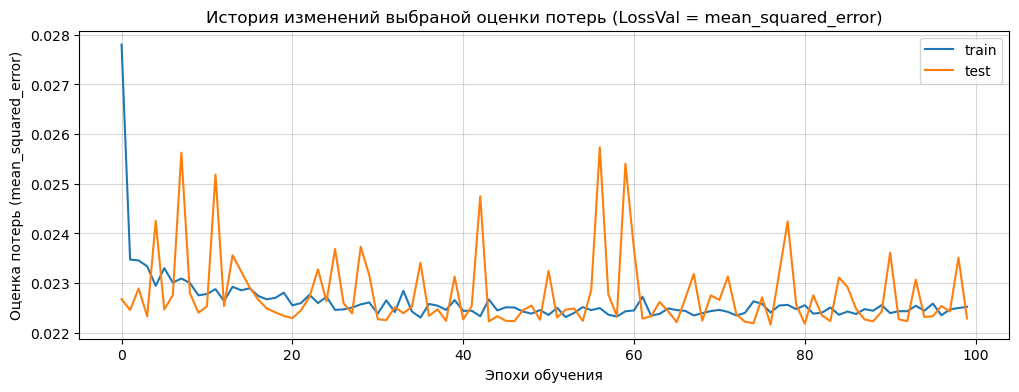

In [50]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
###plt.ylim ( (0, 0.03) ) # Область видимости для оси "Оценки потерь"

Предскажем значения теста

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE :     0.119 (средняя абсолютная ошибка)
MSE :  0.022289 (среднеквадратичная ошибка)
RMSE:  0.149294 (кв. корень из среднеквадратичной ошибки)
R2  :     0.393 (коэфф. детерминации)


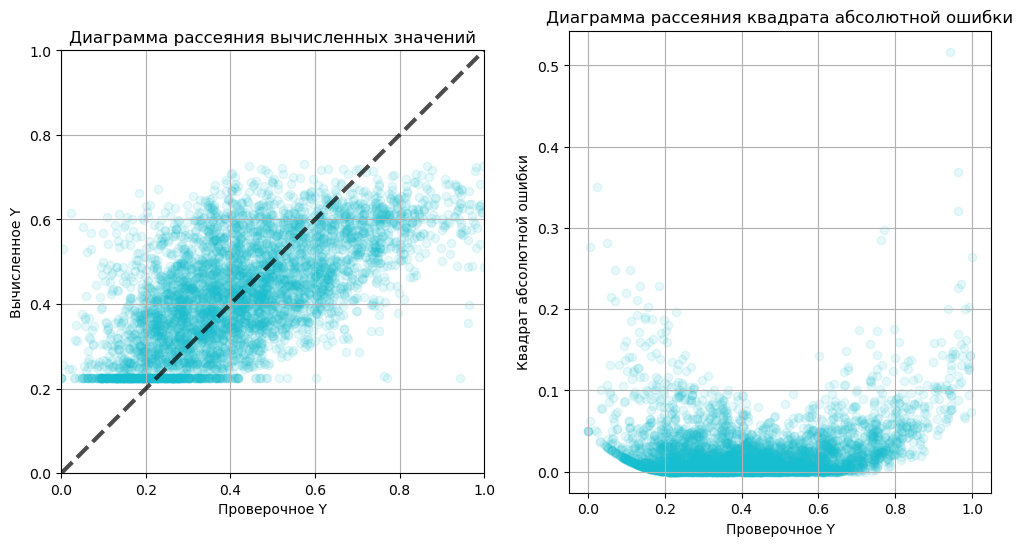

In [51]:
yNorm_pred = model4.predict(xNorm_test_21).reshape(1, -1)[0] # потому что столбец
m_4layers_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

##### Получение весовых коэфф. w_i и bias для модели

In [52]:
printModelWeights(model4)

####################################################################################################
#### Имя слоя:dense_10;  Тип слоя: <class 'keras.src.layers.core.dense.Dense'> ##########
Вид ф-ии активации слоя: relu
Кол-во ВХодов  слоя: 2
Кол-во ВЫХодов слоя: 1000
Кол-во нейронов слоя:    1000

Весовые коэфф. weight_i_j=
[[ 0.01869096 -0.06229813 -0.01303097 ... -0.05621233 -0.01317882
  -0.02346293]
 [-0.07350951 -0.00428565 -0.04204983 ...  0.02781809 -0.05629525
  -0.08091323]]

Весовые коэфф. bias_i_j=
[-0.03017394 -0.06652198 -0.04847013 -0.03741687  0.          0.
 -0.02962667 -0.0681849  -0.05538911 -0.04247209  0.         -0.06002092
 -0.04341786 -0.06002373 -0.04584586 -0.07829984  0.         -0.07641347
 -0.03548748  0.         -0.07705234 -0.0409394  -0.08453383 -0.04237964
 -0.06843369 -0.31201783  0.         -0.05146807 -0.060022   -0.04598697
 -0.06468587 -0.02563859 -0.07134892 -0.03541484 -0.05748801 -0.03883201
 -0.04462868 -0.06499899 -0.0670461   0.         -0.0

In [53]:
my3dplot(
    xNorm_train_21, yNorm_train,  True, # Обучающие x и y, Флаг отображения обучающих точек  (синие)
    xNorm_test_21,  yNorm_test,   True, # Проверочные x и y, Флаг отображения проверочных точек   (оранжевые)
    yNorm_pred,                True, # Вычисленные y, Флаг отображения вычисленной функции  (зелёные)
    x1Name= features21[0],  x2Name=features21[1], y_targetName=target[0],
    pointSize = 5,
    pointTransparency  = 0.2,
    meshTransparency   = 0.8
)

Выбор оптимального количества слоев достигается экспериментально. Нужно брать врассмотрение сложность и точность модели.

### Нейронная сеть m3. Построение модели без скрытых слоев от множества "x" (N_вх->1_вых))

#### Структура

Отличие - у входного слоя теперь 5 входных нейронов.

In [ ]:
totalHistoryLossTrain=[]
totalHistoryLossTest=[]

del model4
model5 = tf.keras.models.Sequential()
model5.add(tf.keras.layers.Input(shape=(5,)))
model5.add(tf.keras.layers.Dense(units=1,  activation=None))

fLoss=tf.keras.losses.MeanSquaredError()
fOptimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
fMetricList  = [tf.keras.losses.MeanSquaredError(), tf.keras.losses.MeanAbsoluteError()]
model5.compile(
    loss      =fLoss,
    optimizer =fOptimizer,
    metrics   = fMetricList
)

#### Первичное и дополнительное обучение

In [55]:
history = model5.fit(
    xNorm_train,
    yNorm_train,
    validation_data=(xNorm_test,yNorm_test),
    epochs=epochForTrain,
    #batch_size=100, # внутри каждой эпохи, проводить обучение пакетами/порциями по batch_size строк
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0317 - mean_absolute_error: 0.1361 - mean_squared_error: 0.0317 - val_loss: 0.0205 - val_mean_absolute_error: 0.1137 - val_mean_squared_error: 0.0205
Epoch 2/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0207 - mean_absolute_error: 0.1142 - mean_squared_error: 0.0206 - val_loss: 0.0202 - val_mean_absolute_error: 0.1130 - val_mean_squared_error: 0.0202
Epoch 3/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0203 - mean_absolute_error: 0.1132 - mean_squared_error: 0.0203 - val_loss: 0.0203 - val_mean_absolute_error: 0.1122 - val_mean_squared_error: 0.0203
Epoch 4/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0203 - mean_absolute_error: 0.1133 - mean_squared_error: 0.0203 - val_loss: 0.0199 - val_mean_absolute_error: 0.1112 - val_mean_squared_error: 0.0199
Epoch 5/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0203 - mean_absolute_error: 0.1133 - mean_squared_error: 0.0203 - val_loss: 0.0199 - 

(0.018, 0.03)

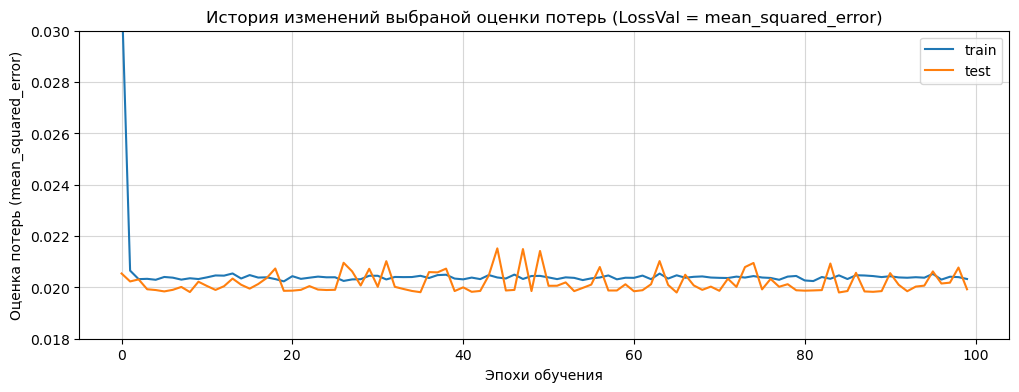

In [56]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
plt.ylim ( (0.018, 0.03) ) # Область видимости для оси "Оценки потерь"

Можем видеть как велика ошибка на начале обучения и как быстро она сводится на нет.

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step
MAE :     0.111 (средняя абсолютная ошибка)
MSE :  0.019923 (среднеквадратичная ошибка)
RMSE:  0.141149 (кв. корень из среднеквадратичной ошибки)
R2  :     0.457 (коэфф. детерминации)


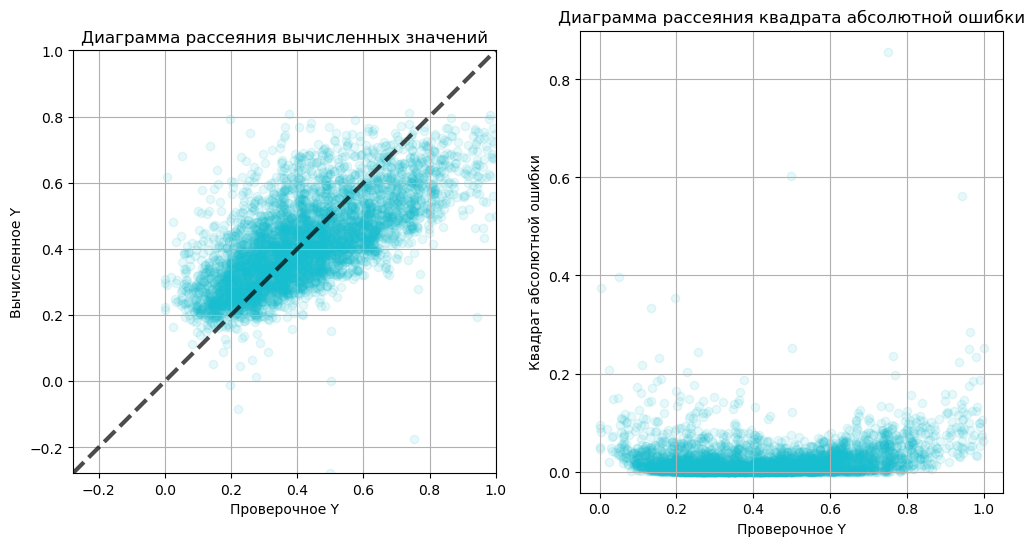

In [57]:
yNorm_pred = model5.predict(xNorm_test).reshape(1, -1)[0] # потому что столбец
m3_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

#### Получение весовых коэфф. w_i и bias

Чем меньше влияет признак тем меньше коэффициент.

In [58]:
printModelWeights(model5)

####################################################################################################
#### Имя слоя:dense_15;  Тип слоя: <class 'keras.src.layers.core.dense.Dense'> ##########
Вид ф-ии активации слоя: linear
Кол-во ВХодов  слоя: 5
Кол-во ВЫХодов слоя: 1
Кол-во нейронов слоя:    1

Весовые коэфф. weight_i_j=
[[ 0.5267661 ]
 [-0.02193108]
 [ 0.31455323]
 [-0.13551034]
 [-0.7219965 ]]

Весовые коэфф. bias_i_j=
[0.27733347]




### Нейронная сеть m4. Построение модели со скрытыми слоями от множества "x" (N_вх-> ??? -> ??? ->1_вых)

#### Структура

Ранее заданные 4 промежуточных слоя с уменьшающимся количеством узлов.

In [ ]:
del model5
model6 = initNewModel()

#### Первичное и дополнительное обучение

In [60]:
history = model6.fit(
    xNorm_train,
    yNorm_train,
    validation_data=(xNorm_test,yNorm_test),
    epochs=epochForTrain,
    #batch_size=100, # внутри каждой эпохи, проводить обучение пакетами/порциями по batch_size строк
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0272 - mean_absolute_error: 0.1241 - mean_squared_error: 0.0272 - val_loss: 0.0186 - val_mean_absolute_error: 0.1079 - val_mean_squared_error: 0.0187
Epoch 2/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0204 - mean_absolute_error: 0.1134 - mean_squared_error: 0.0204 - val_loss: 0.0191 - val_mean_absolute_error: 0.1079 - val_mean_squared_error: 0.0191
Epoch 3/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0200 - mean_absolute_error: 0.1123 - mean_squared_error: 0.0200 - val_loss: 0.0190 - val_mean_absolute_error: 0.1097 - val_mean_squared_error: 0.0190
Epoch 4/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0201 - mean_absolute_error: 0.1128 - mean_squared_error: 0.0201 - val_loss: 0.0210 - val_mean_absolute_error: 0.1137 - val_mean_squared_error: 0.0210
Epoch 5/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0199 - mean_absolute_error: 0.1118 - mean_squared_error: 0.0199 - val_loss: 0.0184 - 

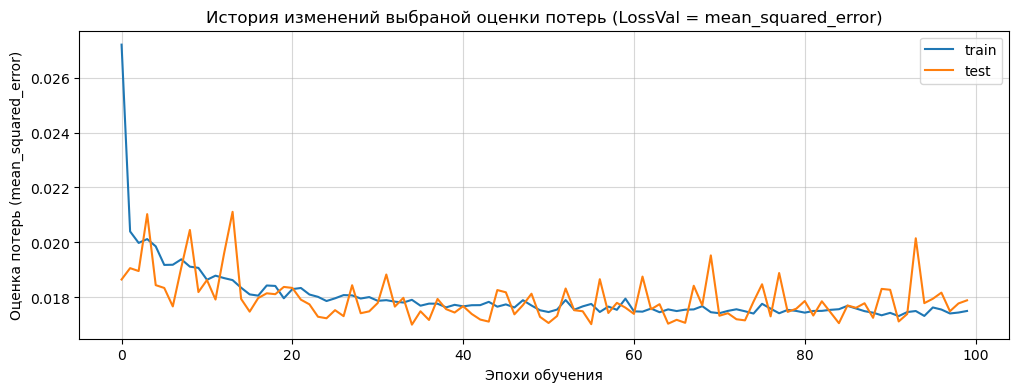

In [61]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
# plt.ylim ( (0.0, 0.03) ) # Область видимости для оси "Оценки потерь"

Ошибка уменьшилась - точность возрасла.

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE :     0.106 (средняя абсолютная ошибка)
MSE :  0.017892 (среднеквадратичная ошибка)
RMSE:  0.133759 (кв. корень из среднеквадратичной ошибки)
R2  :     0.512 (коэфф. детерминации)


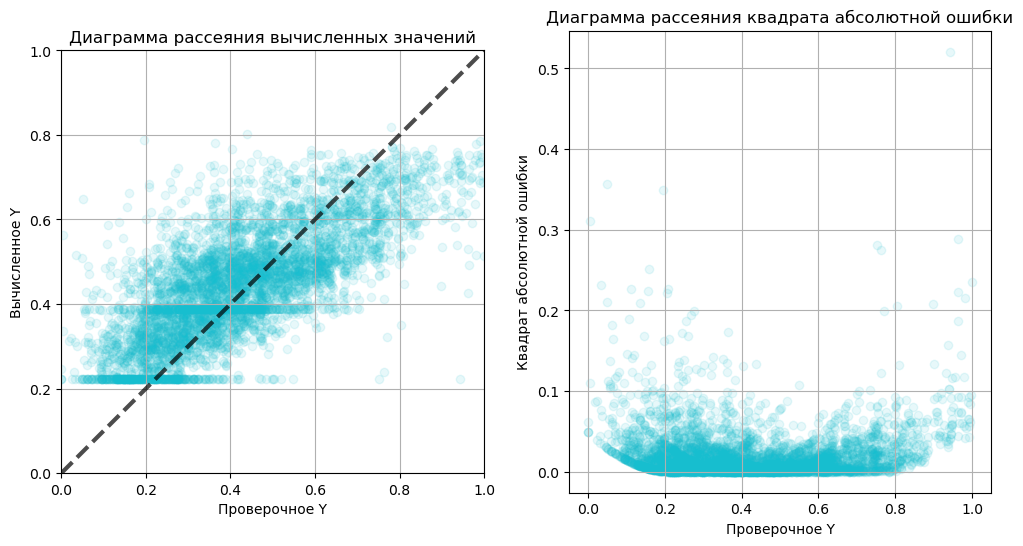

In [62]:
yNorm_pred = model6.predict(xNorm_test).reshape(1, -1)[0] # потому что столбец
m4_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

### Нейронная сеть. Эксперименты с *batch size*

До этого модели тренировались с наборами по умолчанию, размер которых равен [32](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential#:~:text=per%20gradient%20update.-,If%20unspecified%2C%20batch_size%20will%20default%20to%2032,-.%20Do%20not%20specify
). Будем изменять это количество и смотреть на изменение оценок.

#### Размер 64

Исходная модель - 6 слоев.

In [ ]:
del model6
model7 = initNewModel()

Увеличим размер вдвое до 64.

In [64]:
history = model7.fit(
    xNorm_train,
    yNorm_train,
    validation_data=(xNorm_test,yNorm_test),
    epochs=epochForTrain,
    batch_size=64
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1597 - mean_absolute_error: 0.1551 - mean_squared_error: 0.1597 - val_loss: 0.0193 - val_mean_absolute_error: 0.1095 - val_mean_squared_error: 0.0193
Epoch 2/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0202 - mean_absolute_error: 0.1125 - mean_squared_error: 0.0202 - val_loss: 0.0183 - val_mean_absolute_error: 0.1070 - val_mean_squared_error: 0.0183
Epoch 3/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0202 - mean_absolute_error: 0.1125 - mean_squared_error: 0.0202 - val_loss: 0.0186 - val_mean_absolute_error: 0.1074 - val_mean_squared_error: 0.0186
Epoch 4/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0195 - mean_absolute_error: 0.1107 - mean_squared_error: 0.0195 - val_loss: 0.0182 - val_mean_absolute_error: 0.1062 - val_mean_squared_error: 0.0181
Epoch 5/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0195 - mean_absolute_error: 0.1110 - mean_squared_error: 0.0195 - val_loss: 0.0182 - 

(0.015, 0.03)

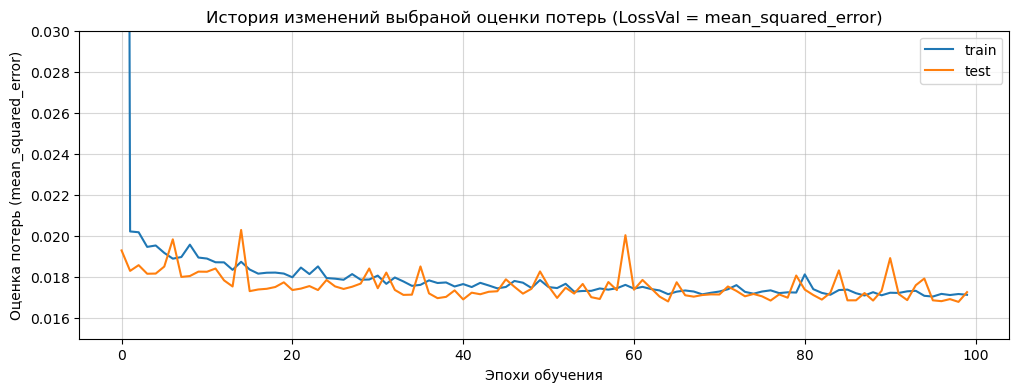

In [65]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
plt.ylim ( (0.015, 0.03) ) # Область видимости для оси "Оценки потерь"

Оценка наилучшая из всех представленных.

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE :     0.102 (средняя абсолютная ошибка)
MSE :  0.017265 (среднеквадратичная ошибка)
RMSE:  0.131398 (кв. корень из среднеквадратичной ошибки)
R2  :     0.530 (коэфф. детерминации)


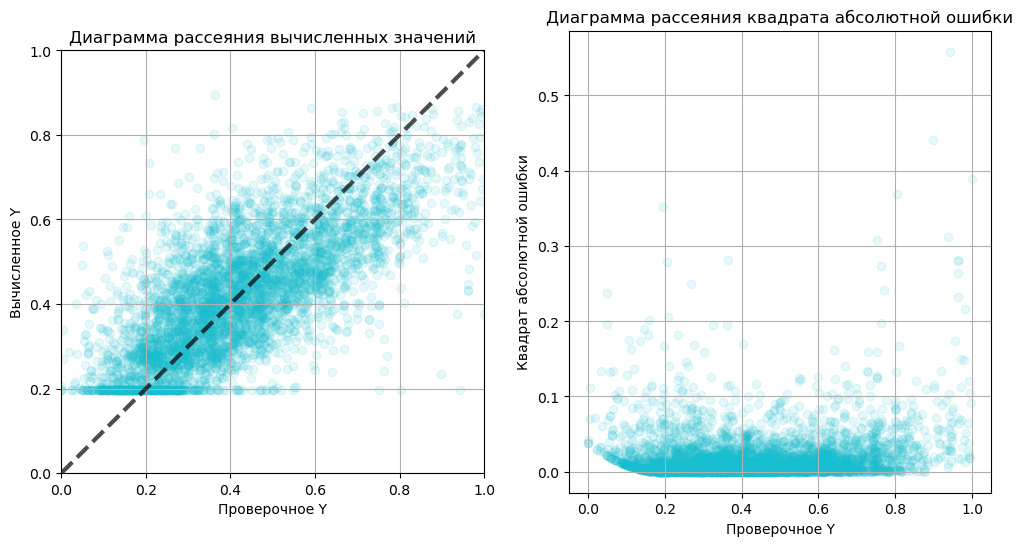

In [ ]:
yNorm_pred = model7.predict(xNorm_test).reshape(1, -1)[0] # потому что столбец
m64_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

#### Размер 128

In [ ]:
del model7
model8 = initNewModel()

In [68]:
history = model8.fit(
    xNorm_train,
    yNorm_train,
    validation_data=(xNorm_test,yNorm_test),
    epochs=epochForTrain,
    batch_size=128
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0903 - mean_absolute_error: 0.1632 - mean_squared_error: 0.0899 - val_loss: 0.0202 - val_mean_absolute_error: 0.1128 - val_mean_squared_error: 0.0202
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0200 - mean_absolute_error: 0.1120 - mean_squared_error: 0.0200 - val_loss: 0.0197 - val_mean_absolute_error: 0.1113 - val_mean_squared_error: 0.0197
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0199 - mean_absolute_error: 0.1116 - mean_squared_error: 0.0199 - val_loss: 0.0181 - val_mean_absolute_error: 0.1057 - val_mean_squared_error: 0.0181
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0191 - mean_absolute_error: 0.1093 - mean_squared_error: 0.0191 - val_loss: 0.0183 - val_mean_absolute_error: 0.1059 - val_mean_squared_error: 0.0182
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0195 - mean_absolute_error: 0.1103 - mean_squared_error: 0.0195 - val_loss: 0.0180 - val_mea

(0.015, 0.03)

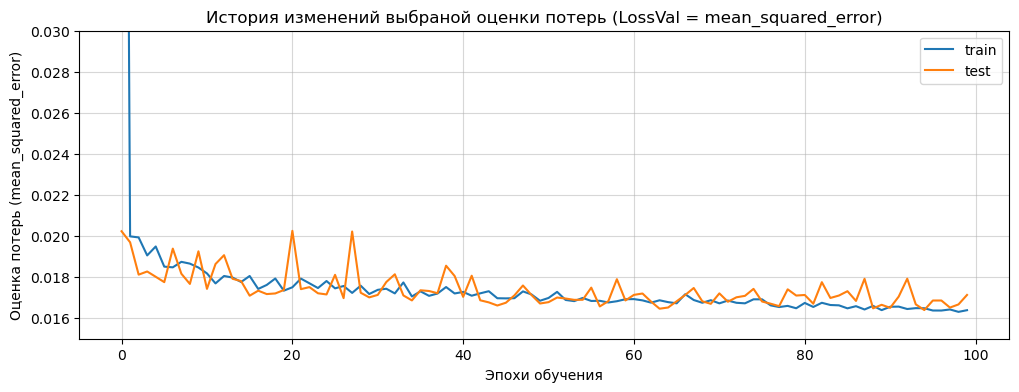

In [69]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
plt.ylim ( (0.015, 0.03) ) # Область видимости для оси "Оценки потерь"

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE :     0.101 (средняя абсолютная ошибка)
MSE :  0.017128 (среднеквадратичная ошибка)
RMSE:  0.130874 (кв. корень из среднеквадратичной ошибки)
R2  :     0.533 (коэфф. детерминации)


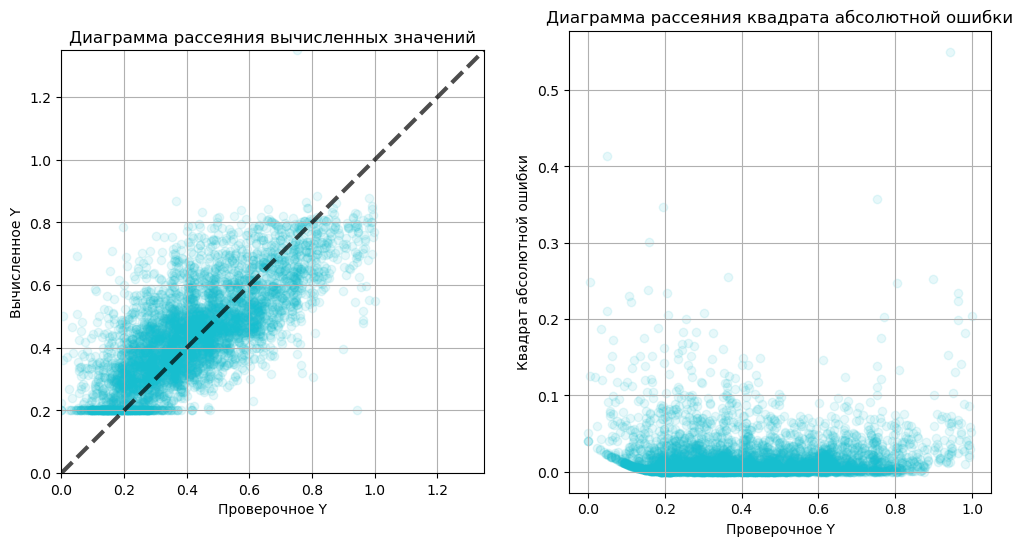

In [70]:
yNorm_pred = model8.predict(xNorm_test).reshape(1, -1)[0] # потому что столбец
m128_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

#### Размер 256

In [ ]:
del model8
model9 = initNewModel()

In [72]:
history = model9.fit(
    xNorm_train,
    yNorm_train,
    validation_data=(xNorm_test,yNorm_test),
    epochs=epochForTrain,
    batch_size=256
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0777 - mean_absolute_error: 0.1810 - mean_squared_error: 0.0773 - val_loss: 0.0198 - val_mean_absolute_error: 0.1109 - val_mean_squared_error: 0.0196
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0201 - mean_absolute_error: 0.1125 - mean_squared_error: 0.0201 - val_loss: 0.0197 - val_mean_absolute_error: 0.1119 - val_mean_squared_error: 0.0196
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0198 - mean_absolute_error: 0.1117 - mean_squared_error: 0.0198 - val_loss: 0.0222 - val_mean_absolute_error: 0.1191 - val_mean_squared_error: 0.0222
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0194 - mean_absolute_error: 0.1104 - mean_squared_error: 0.0194 - val_loss: 0.0183 - val_mean_absolute_error: 0.1062 - val_mean_squared_error: 0.0182
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0196 - mean_absolute_error: 0.1111 - mean_squared_error: 0.0196 - val_loss: 0.0202 - val_m

(0.015, 0.03)

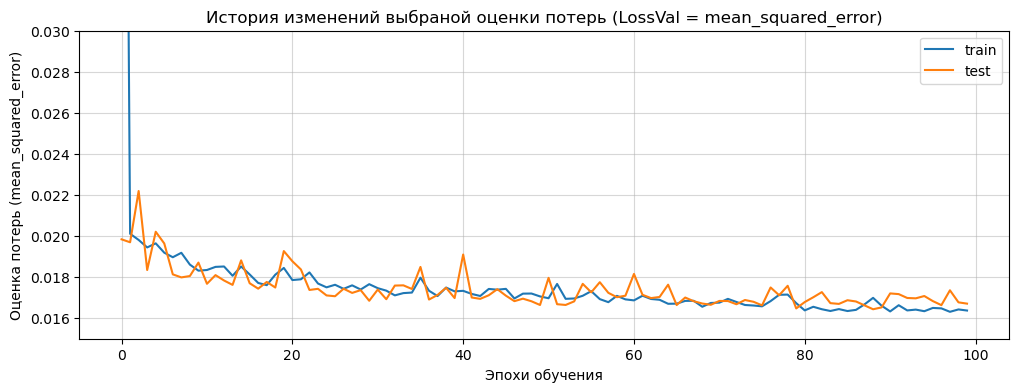

In [73]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
plt.ylim ( (0.015, 0.03) ) # Область видимости для оси "Оценки потерь"

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE :     0.101 (средняя абсолютная ошибка)
MSE :  0.016705 (среднеквадратичная ошибка)
RMSE:  0.129249 (кв. корень из среднеквадратичной ошибки)
R2  :     0.545 (коэфф. детерминации)


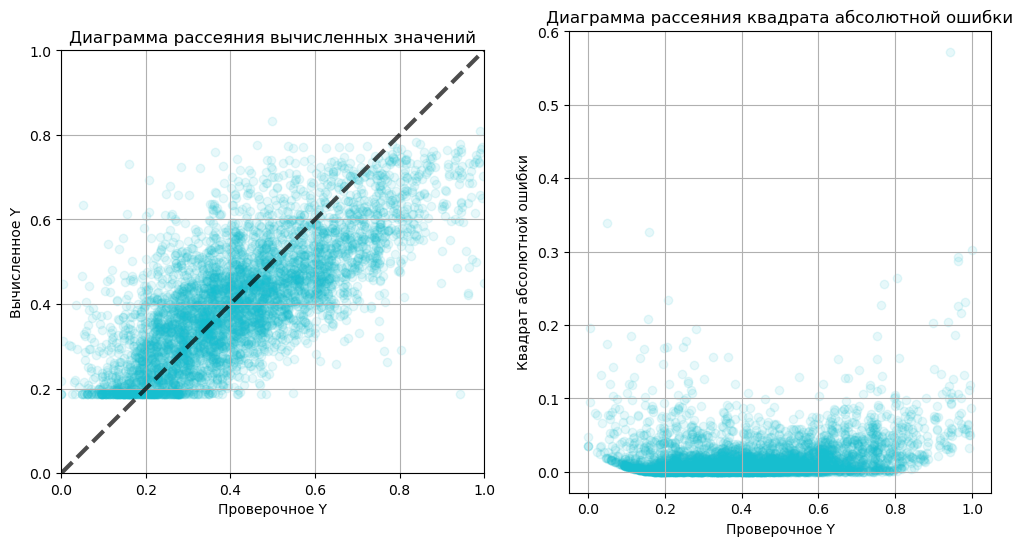

In [74]:
yNorm_pred = model9.predict(xNorm_test).reshape(1, -1)[0] # потому что столбец
m256_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

#### Размер 1024

In [ ]:
del model9
model10 = initNewModel()

In [76]:
history = model10.fit(
    xNorm_train,
    yNorm_train,
    validation_data=(xNorm_test,yNorm_test),
    epochs=epochForTrain,
    batch_size=1024
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.3010 - mean_absolute_error: 0.3503 - mean_squared_error: 0.2835 - val_loss: 0.0399 - val_mean_absolute_error: 0.1545 - val_mean_squared_error: 0.0399
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0299 - mean_absolute_error: 0.1373 - mean_squared_error: 0.0292 - val_loss: 0.0236 - val_mean_absolute_error: 0.1252 - val_mean_squared_error: 0.0236
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0222 - mean_absolute_error: 0.1183 - mean_squared_error: 0.0219 - val_loss: 0.0207 - val_mean_absolute_error: 0.1140 - val_mean_squared_error: 0.0207
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0209 - mean_absolute_error: 0.1148 - mean_squared_error: 0.0209 - val_loss: 0.0201 - val_mean_absolute_error: 0.1124 - val_mean_squared_error: 0.0201
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0205 - mean_absolute_error: 0.1151 - mean_squared_error: 0.0208 - val_loss: 0.0199 - val_m

(0.015, 0.03)

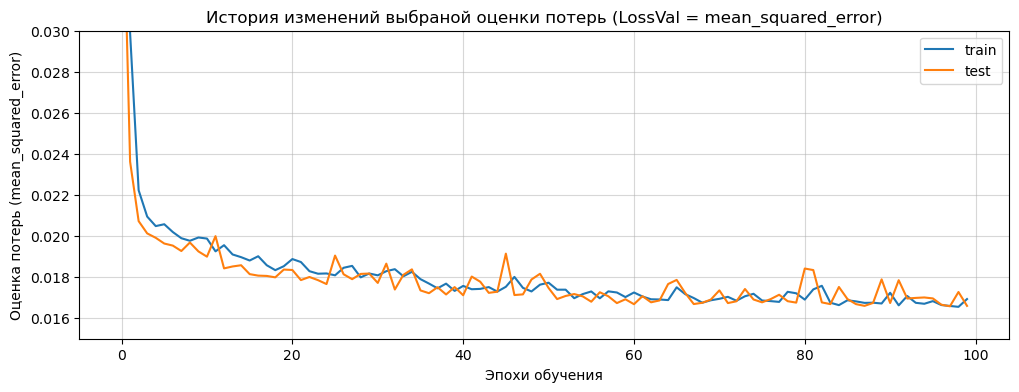

In [77]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
plt.ylim ( (0.015, 0.03) ) # Область видимости для оси "Оценки потерь"

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE :     0.100 (средняя абсолютная ошибка)
MSE :  0.016596 (среднеквадратичная ошибка)
RMSE:  0.128826 (кв. корень из среднеквадратичной ошибки)
R2  :     0.548 (коэфф. детерминации)


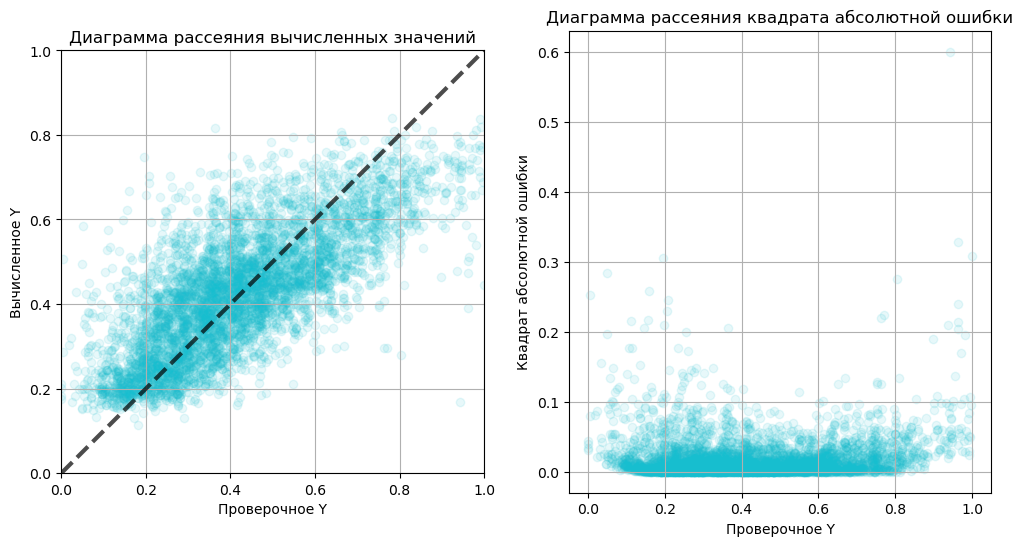

In [78]:
yNorm_pred = model10.predict(xNorm_test).reshape(1, -1)[0] # потому что столбец
m1024_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

### Нейронная сеть. Эксперимент с количеством эпох

#### Длительность в 80 эпох

Остановимся на размере 64. И будем изменять длительность обучения.

In [ ]:
optimal_batch=64
del model10
model11 = initNewModel()

In [80]:
epochForTrainEx80 = 80

history = model11.fit(
    xNorm_train,
    yNorm_train,
    validation_data=(xNorm_test,yNorm_test),
    epochs=epochForTrainEx80,
    batch_size=optimal_batch
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/80
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0580 - mean_absolute_error: 0.1867 - mean_squared_error: 0.0580 - val_loss: 0.0367 - val_mean_absolute_error: 0.1553 - val_mean_squared_error: 0.0367
Epoch 2/80
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0369 - mean_absolute_error: 0.1550 - mean_squared_error: 0.0369 - val_loss: 0.0367 - val_mean_absolute_error: 0.1551 - val_mean_squared_error: 0.0367
Epoch 3/80
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0369 - mean_absolute_error: 0.1550 - mean_squared_error: 0.0369 - val_loss: 0.0367 - val_mean_absolute_error: 0.1552 - val_mean_squared_error: 0.0367
Epoch 4/80
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0369 - mean_absolute_error: 0.1550 - mean_squared_error: 0.0369 - val_loss: 0.0368 - val_mean_absolute_error: 0.1555 - val_mean_squared_error: 0.0367
Epoch 5/80
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0369 - mean_absolute_error: 0.1551 - mean_squared_error: 0.0369 - val_loss: 0.0367 - val_m

(0.015, 0.03)

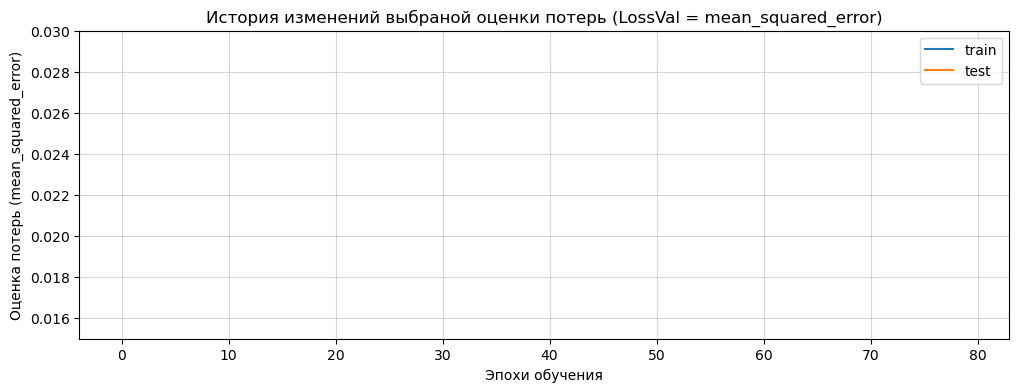

In [81]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
plt.ylim ( (0.015, 0.03) ) # Область видимости для оси "Оценки потерь"

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE :     0.154 (средняя абсолютная ошибка)
MSE :  0.036744 (среднеквадратичная ошибка)
RMSE:  0.191687 (кв. корень из среднеквадратичной ошибки)
R2  :    -0.001 (коэфф. детерминации)


/tmp/ipykernel_434497/3746294819.py:13: RuntimeWarning:

divide by zero encountered in scalar divide



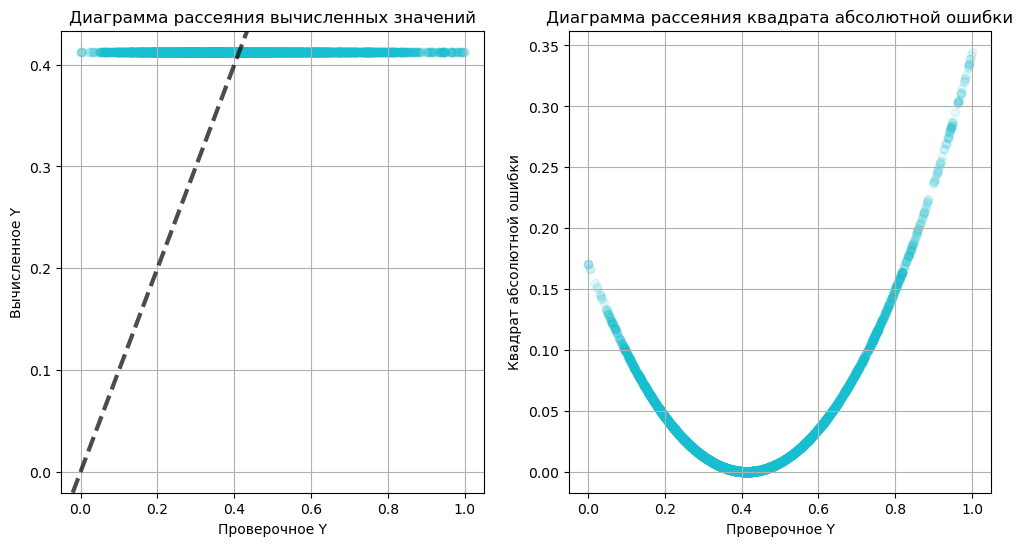

In [82]:
yNorm_pred = model11.predict(xNorm_test).reshape(1, -1)[0] # потому что столбец
m_80ep_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

#### Длительность в 160 эпох

In [ ]:
del model11
model12 = initNewModel()

In [84]:
epochForTrainEx160 = 160

history = model12.fit(
    xNorm_train,
    yNorm_train,
    validation_data=(xNorm_test,yNorm_test),
    epochs=epochForTrainEx160,
    batch_size=optimal_batch
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/160
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0860 - mean_absolute_error: 0.1426 - mean_squared_error: 0.0860 - val_loss: 0.0190 - val_mean_absolute_error: 0.1087 - val_mean_squared_error: 0.0190
Epoch 2/160
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0210 - mean_absolute_error: 0.1145 - mean_squared_error: 0.0210 - val_loss: 0.0191 - val_mean_absolute_error: 0.1091 - val_mean_squared_error: 0.0191
Epoch 3/160
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0204 - mean_absolute_error: 0.1132 - mean_squared_error: 0.0204 - val_loss: 0.0200 - val_mean_absolute_error: 0.1117 - val_mean_squared_error: 0.0200
Epoch 4/160
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0197 - mean_absolute_error: 0.1112 - mean_squared_error: 0.0197 - val_loss: 0.0183 - val_mean_absolute_error: 0.1063 - val_mean_squared_error: 0.0182
Epoch 5/160
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0196 - mean_absolute_error: 0.1105 - mean_squared_error: 0.0196 - val_loss: 0.0235 - 

(0.015, 0.03)

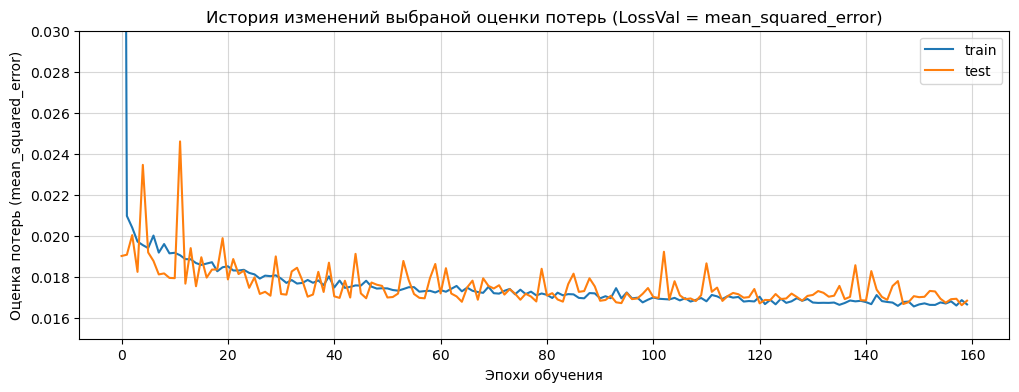

In [85]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
plt.ylim ( (0.015, 0.03) ) # Область видимости для оси "Оценки потерь"

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE :     0.102 (средняя абсолютная ошибка)
MSE :  0.016849 (среднеквадратичная ошибка)
RMSE:  0.129806 (кв. корень из среднеквадратичной ошибки)
R2  :     0.541 (коэфф. детерминации)


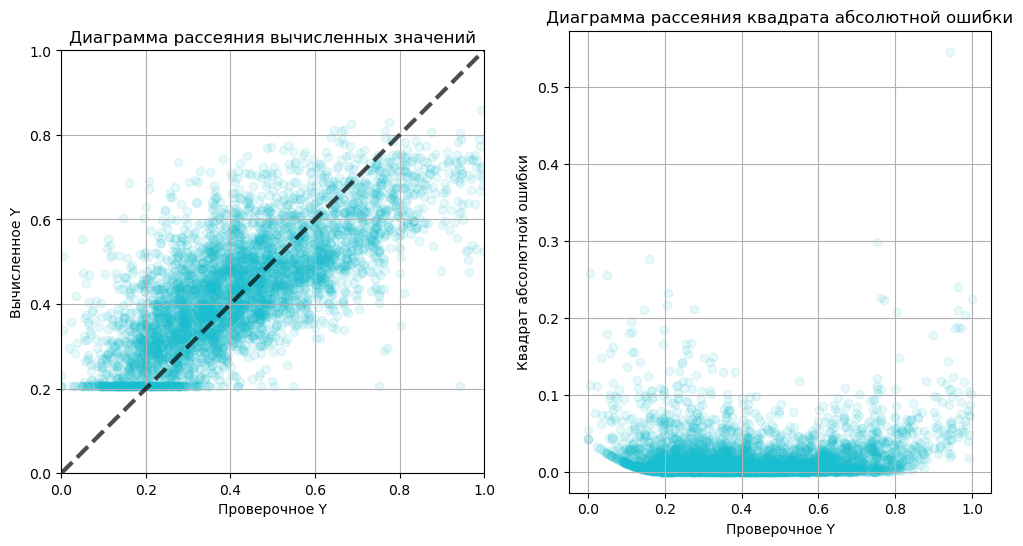

In [86]:
yNorm_pred = model12.predict(xNorm_test).reshape(1, -1)[0] # потому что столбец
m_160ep_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

#### Длительность в 20 эпох

In [ ]:
del model12
model13 = initNewModel()

In [88]:
epochForTrainEx20 = 20

history = model13.fit(
    xNorm_train,
    yNorm_train,
    validation_data=(xNorm_test,yNorm_test),
    epochs=epochForTrainEx20,
    batch_size=optimal_batch
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0285 - mean_absolute_error: 0.1260 - mean_squared_error: 0.0285 - val_loss: 0.0201 - val_mean_absolute_error: 0.1118 - val_mean_squared_error: 0.0200
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0202 - mean_absolute_error: 0.1128 - mean_squared_error: 0.0202 - val_loss: 0.0186 - val_mean_absolute_error: 0.1074 - val_mean_squared_error: 0.0186
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0195 - mean_absolute_error: 0.1107 - mean_squared_error: 0.0195 - val_loss: 0.0185 - val_mean_absolute_error: 0.1082 - val_mean_squared_error: 0.0185
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0196 - mean_absolute_error: 0.1109 - mean_squared_error: 0.0196 - val_loss: 0.0178 - val_mean_absolute_error: 0.1051 - val_mean_squared_error: 0.0178
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0196 - mean_absolute_error: 0.1107 - mean_squared_error: 0.0196 - val_loss: 0.0180 - val_

(0.015, 0.03)

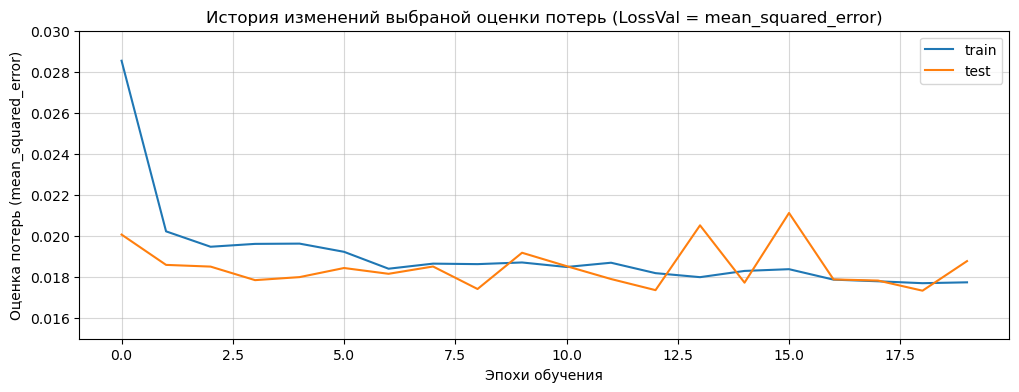

In [89]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
plt.ylim ( (0.015, 0.03) ) # Область видимости для оси "Оценки потерь"

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE :     0.107 (средняя абсолютная ошибка)
MSE :  0.018776 (среднеквадратичная ошибка)
RMSE:  0.137027 (кв. корень из среднеквадратичной ошибки)
R2  :     0.488 (коэфф. детерминации)


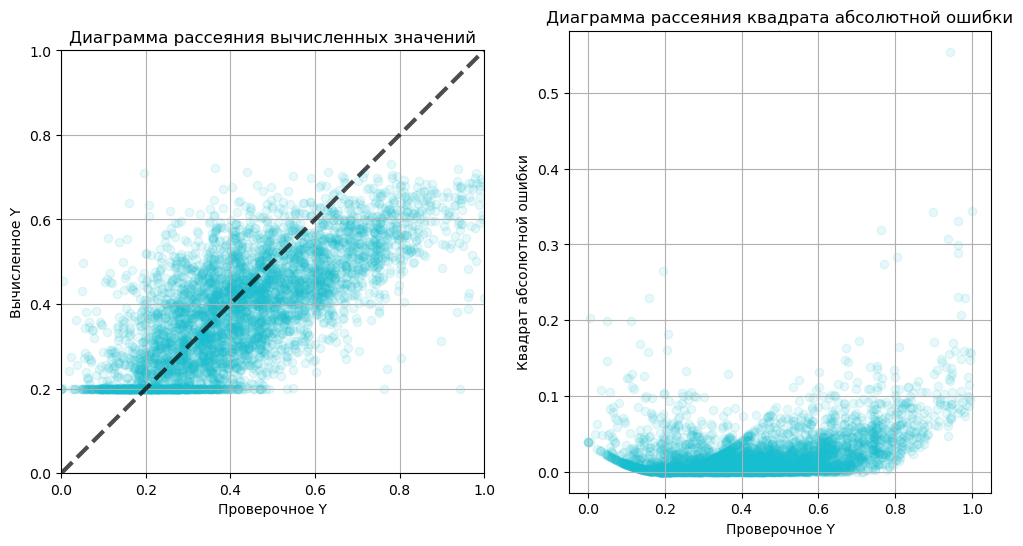

In [90]:
yNorm_pred = model13.predict(xNorm_test).reshape(1, -1)[0] # потому что столбец
m_20ep_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

#### Длительность в 500 эпох

Для этого эскперимента поднимем batch_size до 1024

In [ ]:
del model13
model14 = initNewModel()

In [92]:
epochForTrainEx500 = 500

history = model14.fit(
    xNorm_train,
    yNorm_train,
    validation_data=(xNorm_test,yNorm_test),
    epochs=epochForTrainEx500,
    batch_size=1024
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 1.0499 - mean_absolute_error: 0.5169 - mean_squared_error: 0.9820 - val_loss: 0.0428 - val_mean_absolute_error: 0.1741 - val_mean_squared_error: 0.0428
Epoch 2/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0359 - mean_absolute_error: 0.1521 - mean_squared_error: 0.0358 - val_loss: 0.0307 - val_mean_absolute_error: 0.1452 - val_mean_squared_error: 0.0307
Epoch 3/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0262 - mean_absolute_error: 0.1299 - mean_squared_error: 0.0260 - val_loss: 0.0216 - val_mean_absolute_error: 0.1178 - val_mean_squared_error: 0.0216
Epoch 4/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0213 - mean_absolute_error: 0.1157 - mean_squared_error: 0.0211 - val_loss: 0.0206 - val_mean_absolute_error: 0.1136 - val_mean_squared_error: 0.0206
Epoch 5/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0207 - mean_absolute_error: 0.1130 - mean_squared_error: 0.0204 - val_loss: 0.0199 - val_m

(0.015, 0.03)

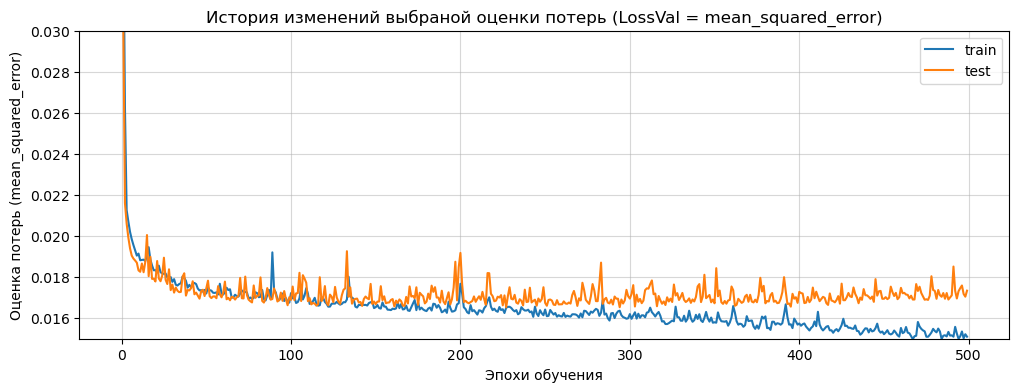

In [93]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
plt.ylim ( (0.015, 0.03) ) # Область видимости для оси "Оценки потерь"

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE :     0.102 (средняя абсолютная ошибка)
MSE :  0.017336 (среднеквадратичная ошибка)
RMSE:  0.131665 (кв. корень из среднеквадратичной ошибки)
R2  :     0.528 (коэфф. детерминации)


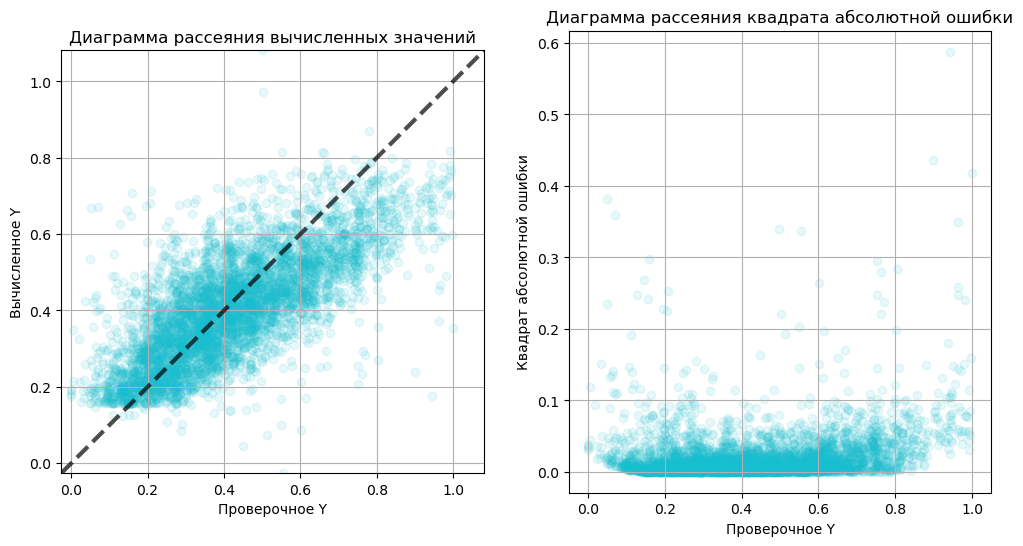

In [94]:
yNorm_pred = model14.predict(xNorm_test).reshape(1, -1)[0] # потому что столбец
m_500ep_stats = stats(yNorm_test, yNorm_pred)
plot_difference(yNorm_test, yNorm_pred)

Можем видеть как расходятся тренировочный и тестовый наборы на графиках ошибок

### Сводка по экспериментам

Эксперимент со слоями

In [98]:
df_model_layers_results = pd.DataFrame(
    [ {'Признаки':features21, 'Число скрытых слоев': "1", "Эпохи обучения": epochForTrain, "R2":m_1layer_stats.get("R2"), "RMSE":m_1layer_stats.get("RMSE")},
      {'Признаки':features21, 'Число скрытых слоев': "2", "Эпохи обучения": epochForTrain, "R2":m_2layers_stats.get("R2"), "RMSE":m_2layers_stats.get("RMSE")},
      {'Признаки':features21, 'Число скрытых слоев': "4", "Эпохи обучения": epochForTrain, "R2":m_4layers_stats.get("R2"), "RMSE":m_4layers_stats.get("RMSE")},
    ]
)
df_model_layers_results

,Признаки,Число скрытых слоев,Эпохи обучения,R2,RMSE
0,"[Median_House_Value, Tot_Rooms]",1,100,0.391872,0.149394
1,"[Median_House_Value, Tot_Rooms]",2,100,0.390338,0.149582
2,"[Median_House_Value, Tot_Rooms]",4,100,0.392686,0.149294


Экспермент со структурой

In [100]:
df_model_results = pd.DataFrame(
    [ {'Признаки':features21, 'Структура': "2вх->1вых", "ЭпохОбучения": epochForTrain, "R2":m1_stats.get("R2"), "RMSE":m1_stats.get("RMSE")},
      {'Признаки':features21, 'Структура': "2вх-> ???  -> ??? ->1вых", "ЭпохОбучения":epochForTrain, "R2":m_4layers_stats.get("R2"), "RMSE":m_4layers_stats.get("RMSE")},
      {'Признаки':features, 'Структура': "5вх->1вых", "ЭпохОбучения":epochForTrain, "R2":m3_stats.get("R2"), "RMSE":m3_stats.get("RMSE")},
      {'Признаки':features, 'Структура': "5вх-> ??? -> ??? ->1вых", "ЭпохОбучения":epochForTrain, "R2":m4_stats.get("R2"), "RMSE":m4_stats.get("RMSE")},
    ]
)
df_model_results

,Признаки,Структура,ЭпохОбучения,R2,RMSE
0,"[Median_House_Value, Tot_Rooms]",2вх->1вых,100,0.367596,0.152346
1,"[Median_House_Value, Tot_Rooms]",2вх-> ??? -> ??? ->1вых,100,0.392686,0.149294
2,"[Median_House_Value, Distance_to_coast, Tot_Ro...",5вх->1вых,100,0.457144,0.141149
3,"[Median_House_Value, Distance_to_coast, Tot_Ro...",5вх-> ??? -> ??? ->1вых,100,0.512497,0.133759


Эксперимент с кусками выборки

In [103]:
df_model_batch_results = pd.DataFrame(
    [ {'Признаки':features, 'Структура': "5вх-> 4 ->1вых", "ЭпохОбучения": epochForTrain, "Размер":64, "R2":m64_stats.get("R2"), "RMSE":m64_stats.get("RMSE")},
      {'Признаки':features, 'Структура': "5вх-> 4 ->1вых", "ЭпохОбучения":epochForTrain, "Размер":128, "R2":m128_stats.get("R2"), "RMSE":m128_stats.get("RMSE")},
      {'Признаки':features, 'Структура': "5вх-> 4 ->1вых", "ЭпохОбучения":epochForTrain, "Размер":256, "R2":m256_stats.get("R2"), "RMSE":m256_stats.get("RMSE")},
      {'Признаки':features, 'Структура': "5вх-> 4 ->1вых", "ЭпохОбучения":epochForTrain, "Размер":1024, "R2":m1024_stats.get("R2"), "RMSE":m1024_stats.get("RMSE")},
    ]
)
df_model_batch_results

,Признаки,Структура,ЭпохОбучения,Размер,R2,RMSE
0,"[Median_House_Value, Distance_to_coast, Tot_Ro...",5вх-> 4 ->1вых,100,64,0.529557,0.131398
1,"[Median_House_Value, Distance_to_coast, Tot_Ro...",5вх-> 4 ->1вых,100,128,0.533298,0.130874
2,"[Median_House_Value, Distance_to_coast, Tot_Ro...",5вх-> 4 ->1вых,100,256,0.544822,0.129249
3,"[Median_House_Value, Distance_to_coast, Tot_Ro...",5вх-> 4 ->1вых,100,1024,0.547791,0.128826


Эксперимент с эпохами

In [106]:
df_model_epoch_results = pd.DataFrame(
    [ {'Признаки':features, 'Структура': "5вх-> 4 ->1вых", "ЭпохОбучения": epochForTrainEx20, "R2":m_20ep_stats.get("R2"), "RMSE":m_20ep_stats.get("RMSE")},
      {'Признаки':features, 'Структура': "5вх-> 4 ->1вых", "ЭпохОбучения":epochForTrainEx80, "R2":m_80ep_stats.get("R2"), "RMSE":m_80ep_stats.get("RMSE")},
      {'Признаки':features, 'Структура': "5вх-> 4 ->1вых", "ЭпохОбучения":epochForTrainEx160, "R2":m_160ep_stats.get("R2"), "RMSE":m_160ep_stats.get("RMSE")},
      {'Признаки':features, 'Структура': "5вх-> 4 ->1вых", "ЭпохОбучения":epochForTrainEx500, "R2":m_500ep_stats.get("R2"), "RMSE":m_500ep_stats.get("RMSE")},
    ]
)
df_model_epoch_results

,Признаки,Структура,ЭпохОбучения,R2,RMSE
0,"[Median_House_Value, Distance_to_coast, Tot_Ro...",5вх-> 4 ->1вых,20,0.488387,0.137027
1,"[Median_House_Value, Distance_to_coast, Tot_Ro...",5вх-> 4 ->1вых,80,-0.001186,0.191687
2,"[Median_House_Value, Distance_to_coast, Tot_Ro...",5вх-> 4 ->1вых,160,0.540891,0.129806
3,"[Median_House_Value, Distance_to_coast, Tot_Ro...",5вх-> 4 ->1вых,500,0.527641,0.131665


### Оценка времени

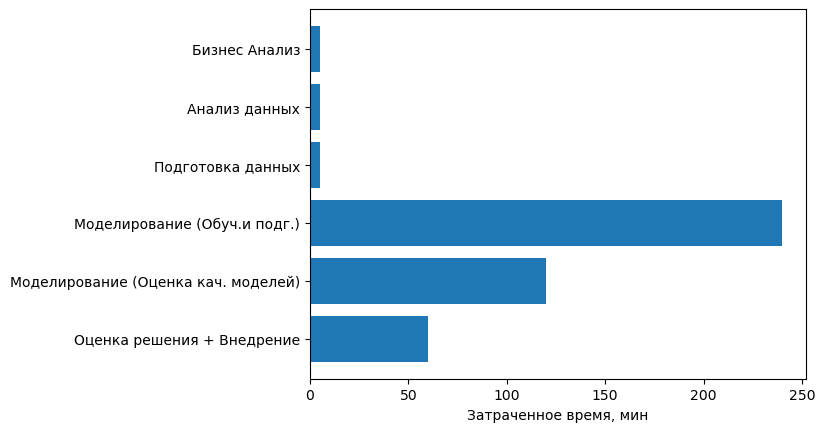

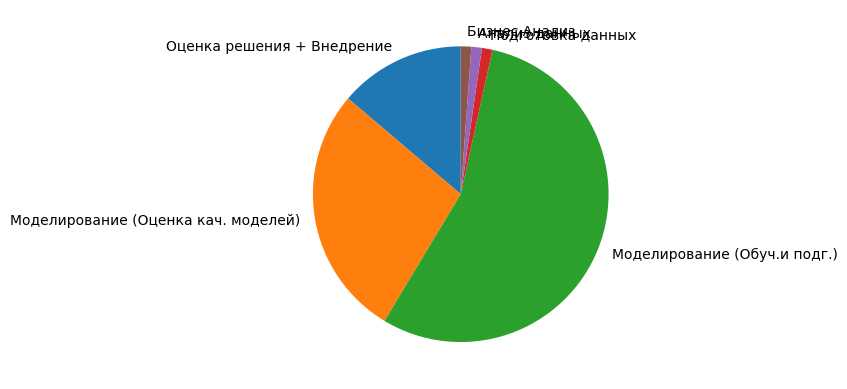

In [107]:
dfSpendTimeLab1 = pd.DataFrame.from_dict(
{
  "1": {"step": "Бизнес Анализ",                       "duration, min" :  5  },
  "2": {"step": "Анализ данных",                       "duration, min" :  5  },
  "3": {"step": "Подготовка данных",                   "duration, min" :  5  },
  "4": {"step": "Моделирование (Обуч.и подг.)",        "duration, min" :  240  },
  "5": {"step": "Моделирование (Оценка кач. моделей)", "duration, min" :  120  },
  "6": {"step": "Оценка решения + Внедрение",          "duration, min" :  60  },
}
, orient="index"
).sort_index(ascending=False)

# Построить столбчатую диаграмму
fig = plt.figure()
plt.barh(y = dfSpendTimeLab1["step"], width= dfSpendTimeLab1["duration, min"], )
plt.xlabel("Затраченное время, мин")

# Построить круговую диаграмму
fig = plt.figure()
plt.pie(x= dfSpendTimeLab1["duration, min"], labels=dfSpendTimeLab1["step"],  startangle = 90 )

plt.show()

---

## Выводы по работе

В ходе выполнения работы был опробован новый тип модели, основанной на стохастическом градиентном спуске. Стохастический характер проявляется, во-первых, в [требовании перемешивать входные данные](https://scikit-learn.ru/stable/modules/sgd.html#id12:~:text=%D0%A3%D0%B1%D0%B5%D0%B4%D0%B8%D1%82%D0%B5%D1%81%D1%8C%2C%20%D1%87%D1%82%D0%BE%20%D0%B2%D1%8B%20%D0%BF%D0%B5%D1%80%D0%B5%D0%BC%D0%B5%D1%88%D0%B8%D0%B2%D0%B0%D0%B5%D1%82%D0%B5%20(shuffle)%20%D0%B2%D0%B0%D1%88%D0%B8%20%D0%BE%D0%B1%D1%83%D1%87%D0%B0%D1%8E%D1%89%D0%B8%D0%B5%20%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D0%B5%20%D0%BF%D0%B5%D1%80%D0%B5%D0%B4%20%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5%D0%BC%20%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8), во-вторых, от изменения зерна генератора случайных чисел изменялись и выходные характеристики модели. Третья особенность - необходимо приводить данные в вид, что дает среднее равное 0 и стандартное отклонение равное 1 - стандартизация; без нее значения модели были неадекватны и отличались на десятки порядков от ожидаемых.

Также был опробован прием кросс-валидации, позволяющий вычислять характеристики моделей на одном наборе данных с исключением некоторой части и тем самым получать более объективные оценки.